In [29]:
%load_ext autoreload
%autoreload 3

# Часть 1 - Методы uplift-моделирования

## Этап 1 - Первичная подготовка данных
- выполнить шаги
    - импортируйте необходимые библиотеки для работы с данными и визуализацией;
    - загрузите датасет;
    - заполните пропуски в датасете, если они есть.

In [92]:
import pandas as pd

data = pd.read_csv('data/initial/uplift_fp_data.csv')
display(data)
data.info()

,recency,history_segment,history,mens,womens,zip_code,newbie,channel,treatment,target
0,10,1,142.44,1,0,1,0,1,1,0
1,6,2,329.08,1,1,2,1,2,0,0
2,7,1,180.65,0,1,1,1,2,1,0
3,9,4,675.83,1,0,2,1,2,0,0
4,2,0,45.34,1,0,0,0,2,1,0
...,...,...,...,...,...,...,...,...,...,...
63995,10,1,105.54,1,0,0,0,2,0,0
63996,5,0,38.91,0,1,0,1,1,0,0
63997,6,0,29.99,1,0,0,1,1,0,0
63998,1,4,552.94,1,0,1,1,0,1,0


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 64000 entries, 0 to 63999
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   recency          64000 non-null  int64  
 1   history_segment  64000 non-null  int64  
 2   history          64000 non-null  float64
 3   mens             64000 non-null  int64  
 4   womens           64000 non-null  int64  
 5   zip_code         64000 non-null  int64  
 6   newbie           64000 non-null  int64  
 7   channel          64000 non-null  int64  
 8   treatment        64000 non-null  int64  
 9   target           64000 non-null  int64  
dtypes: float64(1), int64(9)
memory usage: 4.9 MB


Результат 
- данные загружены
- всего 64000 строки
- пропусков нет (все признаки содержат полный набор 64000 not-null записей)

## Этап 2 - EDA - Проведение исследовательского анализа данных

#### Проверка сбалансированности выборки
- оценим распределение целевой переменной между контрольной и тестовой группами

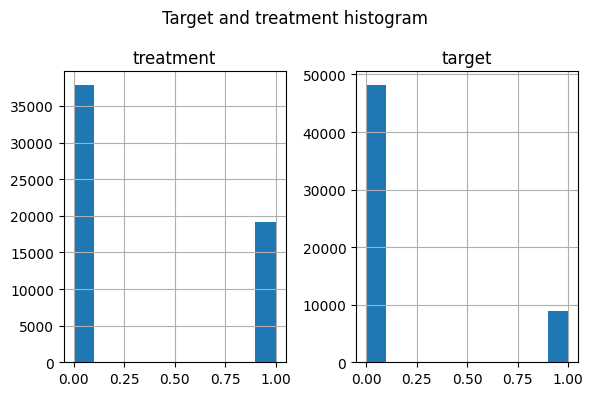

In [192]:
import matplotlib.pyplot as plt 

features_all = ['recency', 'history_segment', 'history', 'mens', 'womens', 'zip_code', 'newbie', 'channel']
treatment = ['treatment']
target = ['target']

# общий обзор гистограммы
data[treatment + target].hist(figsize=(6,4))
plt.suptitle('Target and treatment histogram')
plt.tight_layout()

In [193]:
pd.crosstab(data.target, data.treatment)

treatment,0,1
target,,
0,32051,16090
1,5775,3069


In [101]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt 

def calc_group_data(data: pd.DataFrame, plot: bool = True):
    group_data = data.groupby(by=['treatment']).agg(
        group_count=('target', 'count'),
        target_action=('target', 'sum'),
        conversion=('target', lambda x: round(x.mean(), 6)),
        conversion_std=('target', lambda x: round(x.std(), 6)),
        conversion_var=('target', lambda x: round(x.var(), 6))) \
        .reset_index()
    display(group_data)

    convA = group_data.query('treatment == 0')['conversion'].iat[0]
    convB = group_data.query('treatment == 1')['conversion'].iat[0]

    uplift = convB-convA

    print(f'Прирост конверсии в тестовой группе = {100*(uplift):.2f}%')
    print(f'Относительное увеличение конверсии = {100*(uplift/convA):.2f}%')

    if plot:
        fig,axs = plt.subplots(1,2, figsize=(10,5))

        sns.barplot(data=group_data, x='treatment', y='group_count', label='group count', width=0.5, ax=axs[0])
        sns.barplot(data=group_data, x='treatment', y='target_action', label='target action', width=0.5, ax=axs[0])
        sns.barplot(data=group_data, x='treatment', y='conversion', label='conversion', width=0.5, ax=axs[1])

        axs[0].grid()
        axs[1].grid()
        axs[1].set_ylim((0, 0.18))
        fig.suptitle('Распределение целевой переменной по группам')
        fig.tight_layout()

    return uplift, convA, convB, group_data

,treatment,group_count,target_action,conversion,conversion_std,conversion_var
0,0,42613,6156,0.144463,0.351563,0.123596
1,1,21387,3238,0.151400,0.358447,0.128484


Прирост конверсии в тестовой группе = 0.69%
Относительное увеличение конверсии = 4.80%


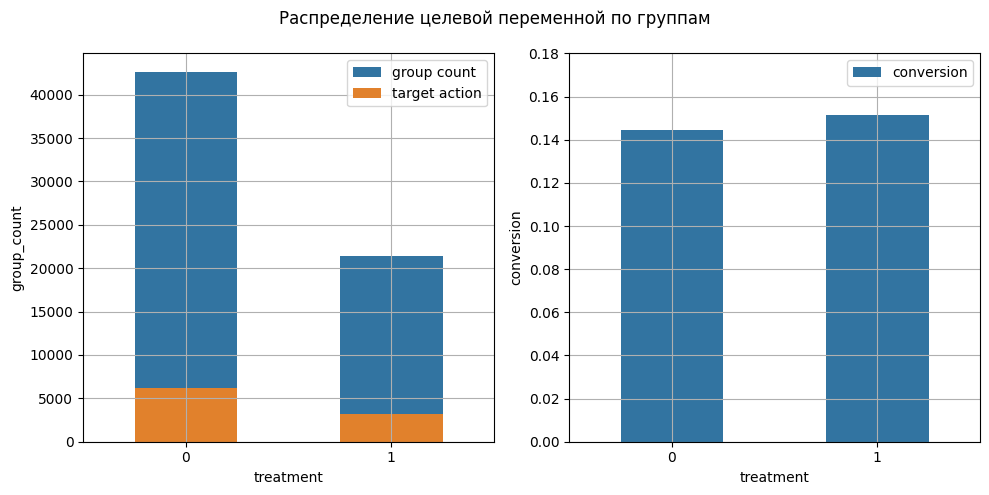

In [13]:
uplift, convA, convB, group_data = calc_group_data(data)

##### Результат
- имеем несбалансированные группы - контрольная группа (без воздействия) содержит в 2 раза больше записей в чем в тестовой (с воздействием)
    - надо будет учесть при выборе подхода uplift-моделирования, такой способ, который это учитывает (X- или R-learner)
- конверсия
    - в контрольной группе = 14,4%
    - в тестовой группе = 15,1%
    - прирост конверсии в тестовой группе = 0.69%
    - относительное увеличение конверсии = 4.78%

#### Проверка на статистическую значимость
Проверка должна показать, что в пределах допустимой ошибки 5% (стандартное отраслевое значение), полученное увеличение конверсии неслучайно (или наоборот)

Анализ способа проверки:

- целевая переменная является дискретной бинарной величиной (воспользовалася ли пользователь промокодом на доставку или нет)
- полученное распределение в двух группах - это распределение Бернулли
    - у этого распределенрия всего два возможных значений - 0 и 1 (два "горба")
    - характеристика такого распределения - это вероятность "p" реализации значения 1
        - среднее значение = p
        - дисперсия = p(1-p)
- для такой выборки "t-test" или другие тесты (Манна-Уитни) для определения "нормального распределения" не подходят
- поэтому необходимо использовать "z-тест для двух выборок" или критерий "хи-квадрат Пирсона"
- так как данных достаточно много, z-тест согласно ЦПТ должен дать удовлетворительный способ проверки

Условие применение z-теста для соответсвия ЦПТ о выборочных средних:

- объекты в выборке независимы (независимые испытания Бернулли) 
    - можем считать, что пользователи и их поведение в Яндекс Еда независимы друг от другах
    - данные не должны содержить дублирущихся пользователей или множества действия одного пользователя - так как это будут уже не независимые испытания
- выборки должны формироваться случайно
    - наличие корреляций в группах между признаками и treatment не выявлено 
- выборки должны содержать достаточное количество данных
    - условие Лапласа - выборка должна содержать минимум n*p >= 10 значений 
    - условие выполняется, так как данных существенно больше (тысячи) 

##### Проверка дубликатов 
- Проверим, нет ли дублированных записей (идентификторов пользователей не предоставлено) - поэтому только по значению

In [2]:
dup_count = len(data[data.duplicated(keep=False)])
print(f'duplicates count: {dup_count} ({100*dup_count/len(data):.2f}%)')

duplicates count: 7868 (12.29%)


Результат - есть дубликаты - 7868 записей (12.29%) 
- их необходимо удалить - иначе выборка не будет удовлетворять требования ЦПТ о независимости наблюдений 

##### Очистка от дублей

In [206]:
data_cleaned = data.drop_duplicates(ignore_index=True)
print(f'Cleaned data size: {len(data_cleaned)}')

# сохранение в файл очищенного датасета
data_cleaned.to_csv('data/uplift_fp_data_cleaned.csv', index=False)

Cleaned data size: 56985


Посмотрим на очищенные данные и обновленное распределение по группам

,treatment,group_count,target_action,conversion,conversion_std,conversion_var
0,0,37826,5775,0.152673,0.359677,0.129367
1,1,19159,3069,0.160186,0.366788,0.134533


Прирост конверсии в тестовой группе = 0.75%
Относительное увеличение конверсии = 4.92%


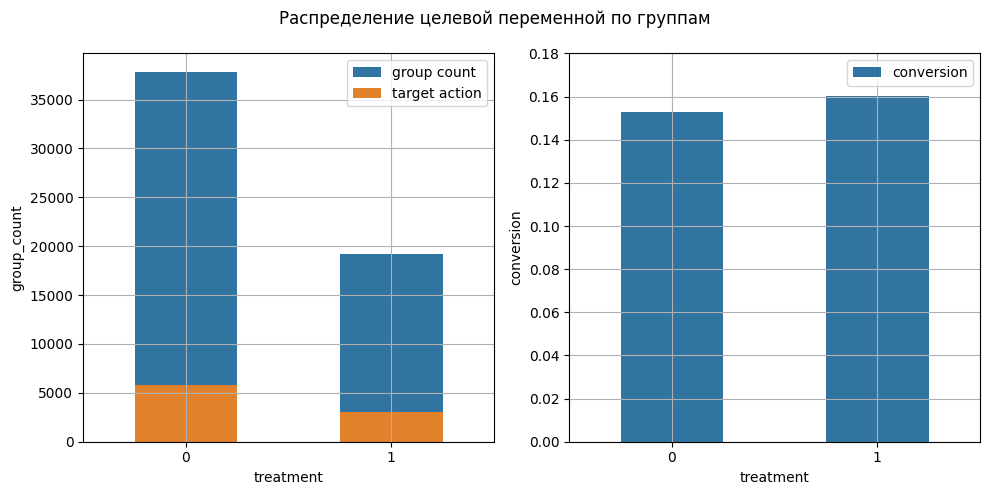

In [102]:
uplift, convA, convB, group_data_cleaned = calc_group_data(data_cleaned)

group_data_cleaned.to_csv('EDA/group_data.csv')

# сохраним в файл
plt.savefig('EDA/targret_by_groups.png', bbox_inches='tight')


##### Результат очистки
- после очистки от дублей (7868 шт / 12.29%) значение конверсии немного выросло
    - Прирост конверсии в тестовой группе = 0.75%
    - Относительное увеличение конверсии = 4.92%

##### Реализация z-теста (z-оценки)

- имеем значения конверсии по группам на основе A/B-теста - будем считать их средними значениями выборки согласно ЦПТ
    - pA, pB - где "p" среднее значение выборки (веротность того, что target = 1)
- определяем разницу двух распределений (B-A) 
    - их среднее delta = разница средних (pB-pA) 
        - их если их среднее в точке 0 - значит выборки не отличаются друг от друга - то есть обе выборки случайны 
            - нулевая гипотеза справедлива
        - если их среднее правее точки 0, значит конверсия в тестовой группе больше чем в контрольной 
            - альтернативная гипотеза справедлива
    - их стандартное отклонение (стандартная ошибка) std_err = сумме стандартных отклонений каждой выборки
- для оценки статистической значимости получения именно такой разницы расчитыаваем z-оценку
    - z-score - это расчет разницы delta (pB-pA) в единицах величины стандартного отклонения
    - z_score = delta / std_err
- определеяем `p-value` - вероятноcть того, что z-оценка отклониться от нуля именно на столько единиц стандартных отклонений при условии, что нулевая гипотеза верна
    - чем сильнее z-оценка отклоняется от нуля, тем более вероятно, что нулевая гипотеза не верна 
    - если p_value больше ожидаемой ошибки 1-ого рода (alpha = 5%), то есть основания отклонить нулевую гипотезу
    - иначе оснований считать, что результаты неслучайны, нет - A/B-тест неуспешный
    - p_value = 2*(1 - CDF(z-score)) - при этом умножаем значение на 2, чтобы учесть вероятность как улучшения базового поведения, так и ухушдения
        

Функция оценки z-score и расчета p-value

In [17]:
import scipy.stats as stat
import numpy as np

def calc_z_score(groupA, groupB):
    # данные группы A
    nA = groupA['group_count'].iat[0]
    pA = groupA['conversion'].iat[0]
    actionsA = groupA['target_action'].iat[0]
    stdA = groupA['conversion_std'].iat[0]
    varA = groupA['conversion_var'].iat[0]

    # данные группы B
    nB = groupB['group_count'].iat[0]
    pB = groupB['conversion'].iat[0]
    actionsB = groupB['target_action'].iat[0]
    stdB = groupB['conversion_std'].iat[0]
    varB = groupB['conversion_var'].iat[0]

    print(f'nA = {nA}, actionsA = {actionsA}, pA = {pA}, stdA = {stdA}, varA = {varA}')
    print(f'nB = {nB}, actionsB = {actionsB}, pB = {pB}, stdB = {stdB}, varB = {varB}')

    # расчет z-score (z-критерий Уэлча для долей)
    std_err = np.sqrt(varA/nA + varB/nB) # стандартная ошибка
    delta = (pB - pA)
    z_score = delta/std_err

    print(f'uplift (pB-pA) = {100*delta:.2f}%, std_err = {std_err:.4f}, z_score = {z_score:.4f}')

    # умножаем значение на 2, чтобы учесть вероятность как улучшения базового поведения, так и ухушдения
    p_value = 2*(1 - stat.norm.cdf(z_score))
    print(f'p_value = {100*p_value:.2f}%')

    # границы 95% доверительного интервала
    alpha = 0.05
    z_crit = stat.norm.ppf(1 - alpha / 2)
    conf_error = z_crit * std_err
    left_bound = delta - conf_error
    right_bound = delta + conf_error
    print(f'95% доверительный интервал для uplit конверсий (pB-pA) = [{100*left_bound:+.2f}%, {100*right_bound:+.2f}%] (допустимое отклонение = {100*conf_error:.2f}%)') 

    return p_value, z_score, (left_bound, right_bound) 

Расчет для исходного датасета (чисто для интереса)

In [18]:
groupA = group_data.query('treatment == 0')
groupB = group_data.query('treatment == 1')

p_value, z_score, (left_bound, right_bound) = calc_z_score(groupA, groupB)

nA = 42613, actionsA = 6156, pA = 0.144463, stdA = 0.351563, varA = 0.123596
nB = 21387, actionsB = 3238, pB = 0.1514, stdB = 0.358447, varB = 0.128484
uplift (pB-pA) = 0.69%, std_err = 0.0030, z_score = 2.3242
p_value = 2.01%
95% доверительный интервал для uplit конверсий (pB-pA) = [+0.11%, +1.28%] (допустимое отклонение = 0.58%)


Расчет для очищенного датасета (рабочий вариант)

In [19]:
groupA = group_data_cleaned.query('treatment == 0')
groupB = group_data_cleaned.query('treatment == 1')

p_value, z_score, (left_bound, right_bound) = calc_z_score(groupA, groupB)

nA = 37826, actionsA = 5775, pA = 0.152673, stdA = 0.359677, varA = 0.129367
nB = 19159, actionsB = 3069, pB = 0.160186, stdB = 0.366788, varB = 0.134533
uplift (pB-pA) = 0.75%, std_err = 0.0032, z_score = 2.3250
p_value = 2.01%
95% доверительный интервал для uplit конверсий (pB-pA) = [+0.12%, +1.38%] (допустимое отклонение = 0.63%)


##### Результат z-оценки
- получена оценка `p-value` = 2.01% ниже допустимой alpha-ошибки 5%
- разница конверсий (полученный uplift) = 0.75% входит в 95% доверительный интервал = [0.12%, 1.38%]
    - и интервал не содержит значения = 0 (что означало бы возможность ухудшения конверсии)
- таким образом, можно сделать вывод, что полученное увеличение конверсии является статистически значимым
    - и довольно надежным - вероятность ошибки = 2%
    - вероятный максимальный uplift = 1.38%
    - вероятный минимальный uplift = 0.12%


##### [Опционально] Выполним дополнительно оценку значимости по критерию "Хи-квадрат" Пирсона

Проверяет есть ли взаимосвязь между двумя группами и их конверсиями

Для расчета строится "таблица сопряжения" и вычисляется коэффициент "хи-квадрат" (chi2)
- чем более данные отличаются в группах от ожидаемых (при условии их вероятной одинаковости)
    - тем больше значение chi2 и тем меньше вероятность такого значения p-value

In [281]:
import scipy.stats as stat
import numpy as np

nA = groupA['group_count'].iat[0]
actionsA = groupA['target_action'].iat[0]

nB = groupB['group_count'].iat[0]
actionsB = groupB['target_action'].iat[0]

chi_data = [[actionsA, nA - actionsA], [actionsB, nB - actionsB]]

chi2, p_value, _, _ = stat.chi2_contingency(chi_data)

print(f'Критерий хи-квадрат = {chi2:.2f}, p_value = {100*p_value:.2f}%') 


Критерий хи-квадрат = 5.42, p_value = 1.99%


Результат
- полученное значение `p_value` от критерия хи-квадрат также < 5%, и почти совпало с `p_value` для z-оценки (2.01%)
- значит, статистическая значимость также подтверждается

### Проверка наличия выбросов

Построим гистограммы по всем признакам (определение частоты появления в выборке)

In [105]:
import pandas as pd

data = pd.read_csv('data/uplift_fp_data_cleaned.csv')

/tmp/ipykernel_2225/3118041268.py:9: UserWarning: To output multiple subplots, the figure containing the passed axes is being cleared.
  data[features_all].hist(bins=12, ax=ax)


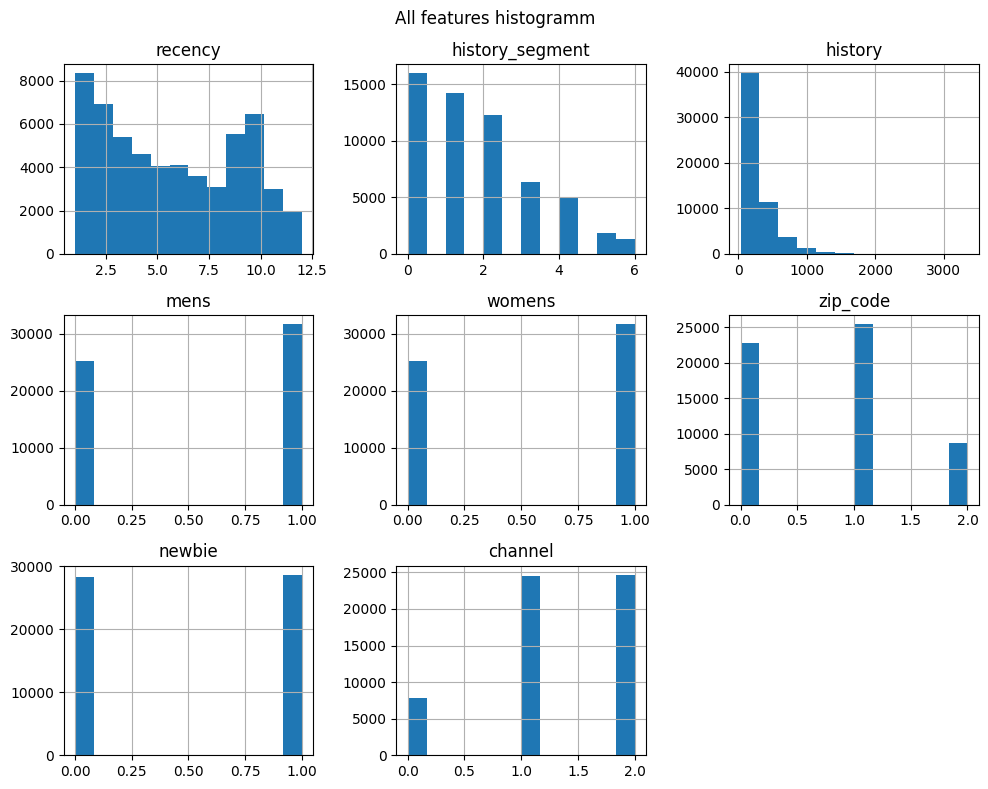

In [106]:
import matplotlib.pyplot as plt 
import seaborn as sns

features_all = ['recency', 'history_segment', 'history', 'mens', 'womens', 'zip_code', 'newbie', 'channel']
treatment = ['treatment']
target = ['target']

ax = plt.subplot(1,1,1)
data[features_all].hist(bins=12, ax=ax)
ax.figure.set_size_inches((10,8))
ax.figure.suptitle('All features histogramm')
ax.figure.tight_layout()

# сохраним в файл
ax.figure.savefig('EDA/features_histogram.png', bbox_inches='tight')


Рассмотрим дополнительно признак `history` - так как значения очень малые на хвосте, применим логарифмический масштаб

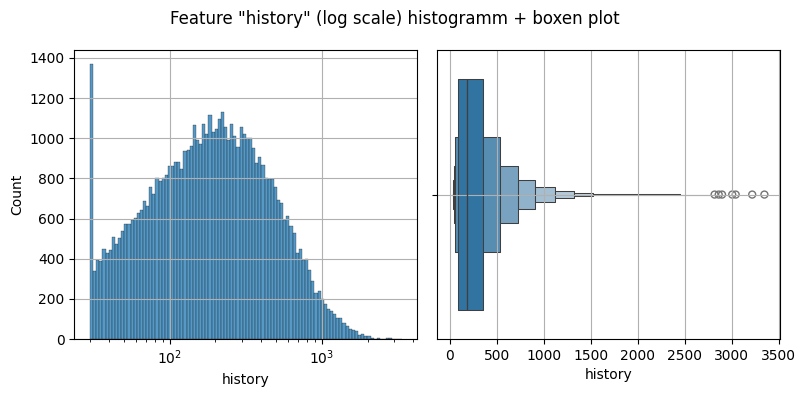

In [99]:
fig, axs = plt.subplots(1,2)
fig.set_size_inches(8,4)

ax1 = sns.histplot(data, x='history', log_scale=True, bins=100, ax=axs[0])
ax1.grid()
ax2 = sns.boxenplot(data, x='history', ax=axs[1])
ax2.grid()

fig.suptitle('Feature "history" (log scale) histogramm + boxen plot')
fig.tight_layout()

# сохраним в файл
fig.savefig('EDA/history_feature_outliers.png', bbox_inches='tight')


Что это за горб в районе значения "30"

In [122]:
data.query('history <= 30')['history'].describe()

count    981.000000
mean      29.990020
std        0.000451
min       29.990000
25%       29.990000
50%       29.990000
75%       29.990000
max       30.000000
Name: history, dtype: float64

#### Результат
- в основном признаки распределены более-менее равномерно
- выбивается только признак "history" 
    - со значениями более 2000 в райное 10 и менее записей
    - с дополнительным горбом в значении = 29.99 (что за волшебное число ..)

### Построение корреляций

- проанализируем взаимодействие признаков, целевой переменной (target) и воздействия (treatment) 
- выполним анализ с помощью корреляционной матрицы признаков и визуализируем ее с помощью "тепловой карты"
- построим графики зависимостей между признаками 

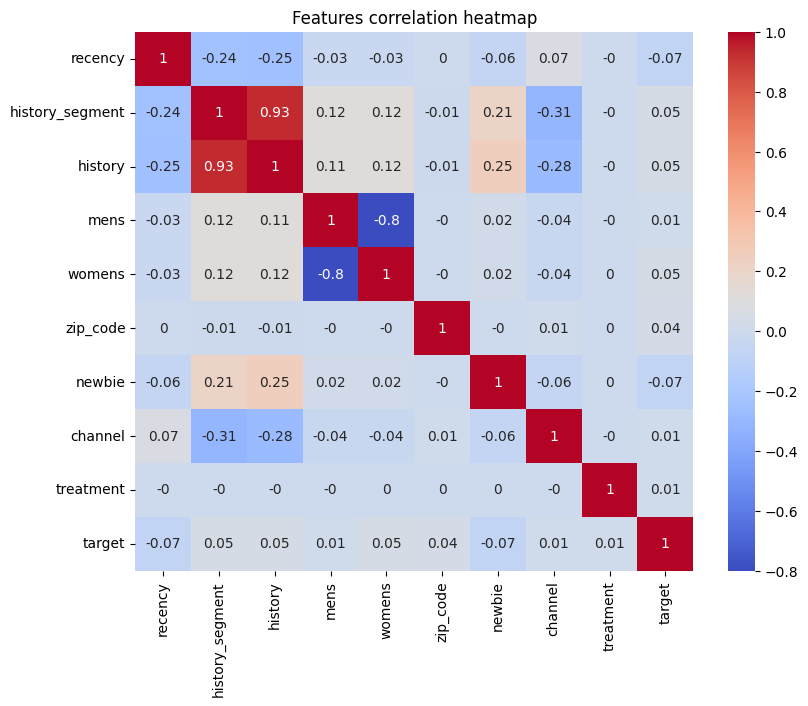

In [210]:
import matplotlib.pyplot as plt 
import seaborn as sns

correlation_data = data.corr()

plt.figure(figsize=(9, 7))
ax = sns.heatmap(correlation_data.round(2),  annot=True, cmap="coolwarm")
ax.set_title('Features correlation heatmap')

# сохраним в файл
ax.figure.savefig('EDA/corr-heatmap.png', bbox_inches='tight')

Результат
- корреляции между признаками и таргетом не выявлено
- корреляции между признаками и воздействием (treatment) не выявлено
- сильная корреляция между признаками:
    - history_segment и history - очевидно history_segent это категориальный признак, который дает большее значение для большего history
- сильная отрицательная корреляция между признаками:
    - mens и womens - логично, тут полная противоположность полов

Посмотрим зависимости признаков с высокой корреляцией 

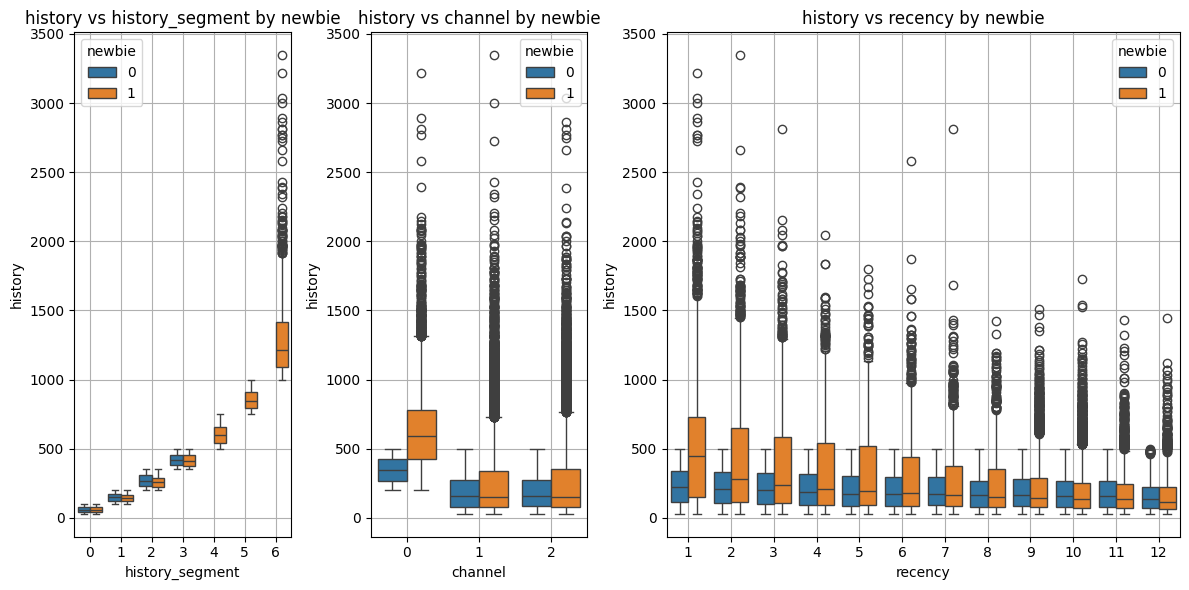

In [19]:
import matplotlib.pyplot as plt 
import seaborn as sns

fig = plt.figure(figsize=(12,6))

ax1 = plt.subplot2grid((1,4), (0,0))
ax1 = sns.boxplot(data_cleaned, x='history_segment', y='history', hue='newbie', ax=ax1)
ax1.set_title('history vs history_segment by newbie')
ax1.grid(True)

ax2 = plt.subplot2grid((1,4), (0,1))
ax2 = sns.boxplot(data_cleaned, x='channel', y='history', hue='newbie', ax=ax2)
ax2.set_title('history vs channel by newbie')
ax2.grid(True)

ax3 = plt.subplot2grid((1, 4), (0,2), colspan=2)
ax3 = sns.boxplot(data_cleaned, x='recency', y='history', hue='newbie', ax=ax3)
ax3.set_title('history vs recency by newbie')
ax3.grid(True)

plt.tight_layout()

# сохраним в файл
fig.savefig('EDA/history-vs-features.png', bbox_inches='tight')

Результат
- интересно, что б'ольшие суммы трат (покупок) совершили только "новички" (newbie) в категориях 4-6 (от 500р.)
- странно, что старые клиенты делали покупки в каждом месяце (recency) на очень малые суммы - 100-300р - похоже, что это шаурма .. или гамбургер, но никак не рестораны 
- новички тоже совершали покупки в каждом месяце, на чуть большие суммы в среднем и с гораздо большим количеством выбросов на суммы от 1000р и выше 
- чуть больше покупоку совершили в канале "0", в каналах "1", "2" - распределение сумм покупок одинаковое

Посмотрим зависимости признаков и таргета

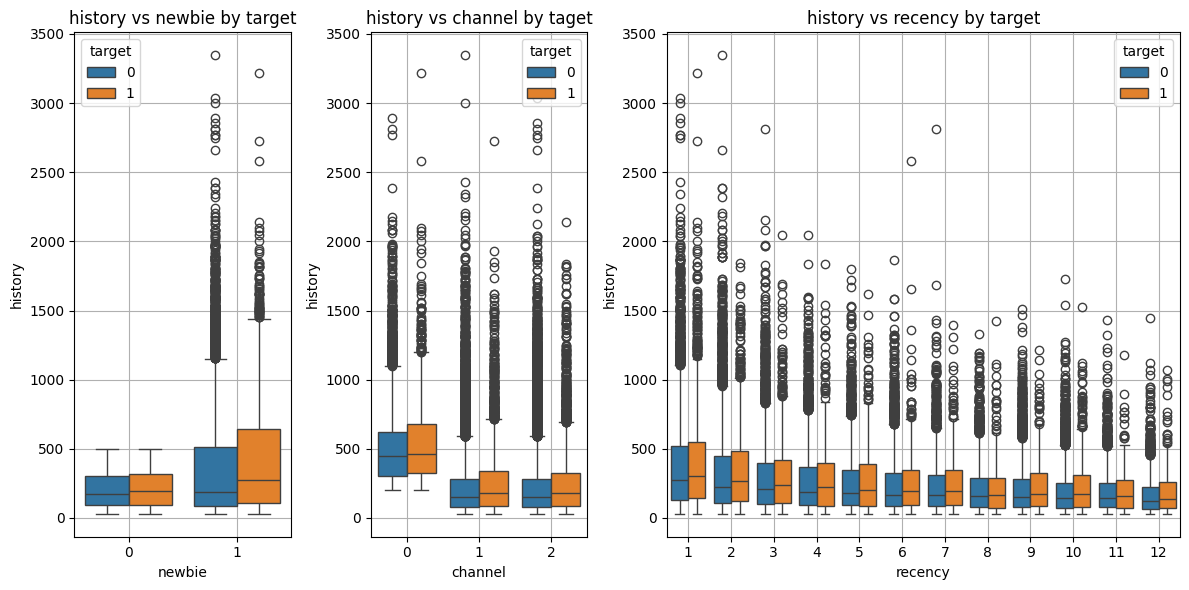

In [20]:
import matplotlib.pyplot as plt 
import seaborn as sns

fig = plt.figure(figsize=(12,6))

ax1 = plt.subplot2grid((1,4), (0,0))
ax1 = sns.boxplot(data_cleaned, x='newbie', y='history', hue='target', ax=ax1)
ax1.set_title('history vs newbie by target')
ax1.grid(True)

ax2 = plt.subplot2grid((1,4), (0,1))
ax2 = sns.boxplot(data_cleaned, x='channel', y='history', hue='target', ax=ax2)
ax2.set_title('history vs channel by taget')
ax2.grid(True)

ax3 = plt.subplot2grid((1, 4), (0,2), colspan=2)
ax3 = sns.boxplot(data_cleaned, x='recency', y='history', hue='target', ax=ax3)
ax3.set_title('history vs recency by target')
ax3.grid(True)

plt.tight_layout()

# сохраним в файл
fig.savefig('EDA/history-vs-target.png', bbox_inches='tight')

Результат
- целевая переменная довольно равномерно распределена по всем категориям - среди новичков, по каналам, по вовлеченности (recency)

Посмотрим зависимости признаков и воздействия

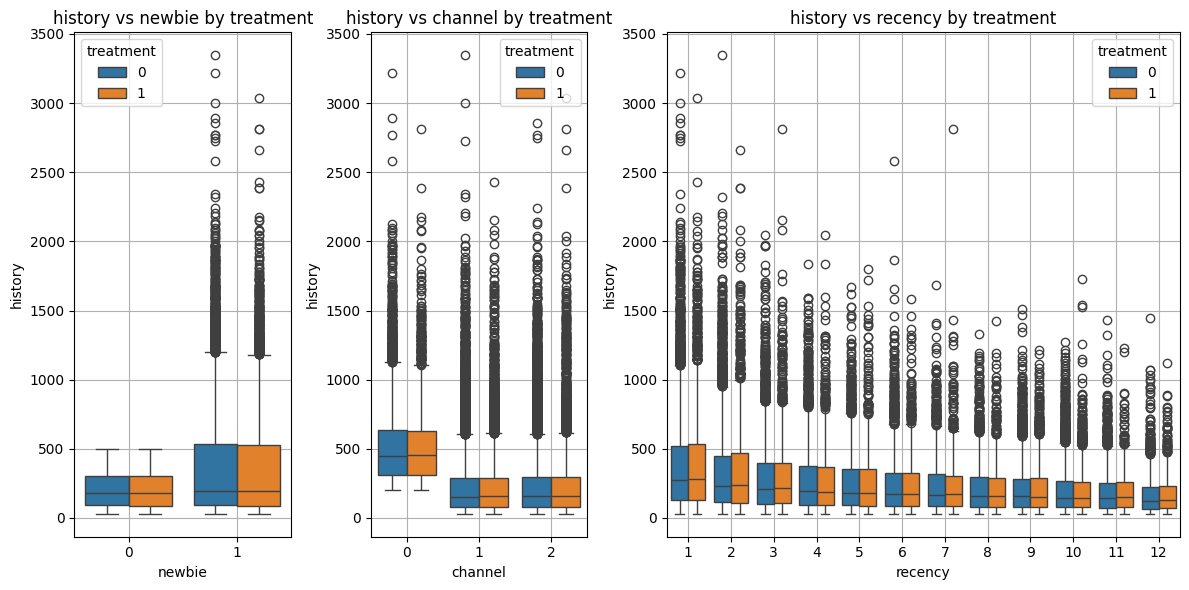

In [21]:
import matplotlib.pyplot as plt 
import seaborn as sns

fig = plt.figure(figsize=(12,6))

ax1 = plt.subplot2grid((1,4), (0,0))
ax1 = sns.boxplot(data_cleaned, x='newbie', y='history', hue='treatment', ax=ax1)
ax1.set_title('history vs newbie by treatment')
ax1.grid(True)

ax2 = plt.subplot2grid((1,4), (0,1))
ax2 = sns.boxplot(data_cleaned, x='channel', y='history', hue='treatment', ax=ax2)
ax2.set_title('history vs channel by treatment')
ax2.grid(True)

ax3 = plt.subplot2grid((1, 4), (0,2), colspan=2)
ax3 = sns.boxplot(data_cleaned, x='recency', y='history', hue='treatment', ax=ax3)
ax3.set_title('history vs recency by treatment')
ax3.grid(True)

plt.tight_layout()

# сохраним в файл
fig.savefig('EDA/history-vs-treatment.png', bbox_inches='tight')

Результат
- воздействие почти идеально поровну распределено по всем категориям - среди новичков, по каналам, по вовлеченности (recency)

Посмотрим на распределение на целевой переменной/конверсии и воздействия среди новичков и старых клиентов

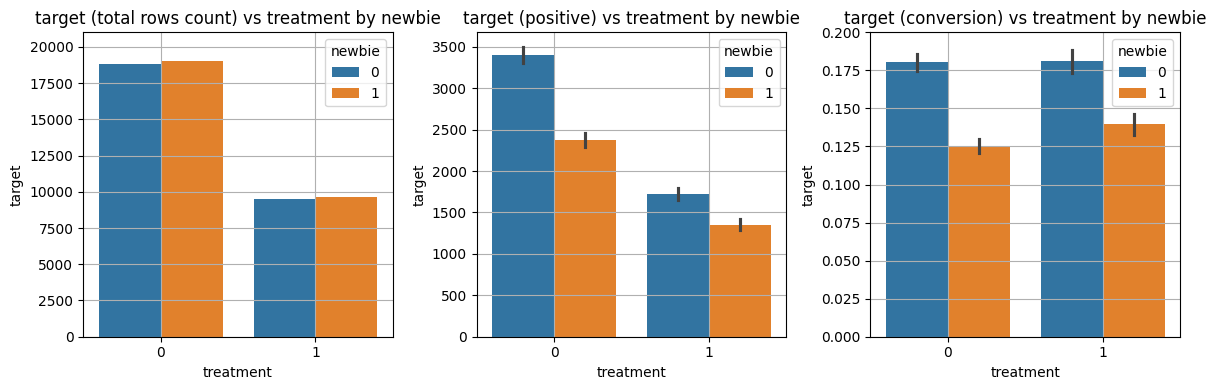

In [22]:
fig, axs = plt.subplots(1,3, figsize=(12,4))

ax1 = sns.barplot(data_cleaned, x='treatment', y='target', hue='newbie', estimator='size', ax=axs[0])
ax1.set_ylim(0, 21000)
ax1.set_title('target (total rows count) vs treatment by newbie')
ax1.grid(True)

ax2 = sns.barplot(data_cleaned, x='treatment', y='target', hue='newbie', estimator='sum', ax=axs[1])
ax2.set_title('target (positive) vs treatment by newbie')
ax2.grid(True)

ax3 = sns.barplot(data_cleaned, x='treatment', y='target', hue='newbie', estimator='mean', ax=axs[2])
ax3.set_ylim(0, 0.2)
ax3.set_title('target (conversion) vs treatment by newbie')
ax3.grid(True)

fig.tight_layout()

# сохраним в файл
fig.savefig('EDA/target-vs-treatment-by-newbie.png', bbox_inches='tight')


In [ ]:
group_newbie = data_cleaned.groupby(by=['treatment', 'newbie']).agg(
        group_count=('target', 'count'),
        target_action=('target', 'sum'),
        conversion=('target', lambda x: round(x.mean(), 6))).reset_index()
display(group_newbie)
# сохраним в файл
group_newbie.to_csv('EDA/group_newbie.csv')

non_treat_olds = group_newbie[(group_newbie['treatment'] == 0) & (group_newbie['newbie'] == 0)]['conversion'].values[0]
treat_olds = group_newbie[(group_newbie['treatment'] == 1) & (group_newbie['newbie'] == 0)]['conversion'].values[0]
uplift_olds = treat_olds - non_treat_olds 

non_treat_news = group_newbie[(group_newbie['treatment'] == 0) & (group_newbie['newbie'] == 1)]['conversion'].values[0]
treat_news = group_newbie[(group_newbie['treatment'] == 1) & (group_newbie['newbie'] == 1)]['conversion'].values[0]
uplift_news = treat_news - non_treat_news 

print(f'uplift for old cliens = {100*uplift_olds:.2f}%, relative uplift = {100*uplift_olds/non_treat_olds:.2f}%')
print(f'uplift for new cliens = {100*uplift_news:.2f}%, relative uplift = {100*uplift_news/non_treat_news:.2f}%')

,treatment,newbie,group_count,target_action,conversion
0,0,0,18834,3400,0.180525
1,0,1,18992,2375,0.125053
2,1,0,9508,1722,0.181111
3,1,1,9651,1347,0.139571


uplift for old cliens = 0.06%, relative uplift = 0.32%
uplift for new cliens = 1.45%, relative uplift = 11.61%


Результат
- как было ранее отмечено - воздействие получило примерно половино выборки
- воздействие одинаково распределено на новых и старых клиентов
- в обеих группах ("без воздействия" и "с воздействием") больше целевых действий выполнили "старые клиенты"
    - конверсия без воздействия
        - старые клиенты - 18,05%
        - новые клиенты - 12,50%
    - конверсия с воздействием
        - старые клиенты - 18,11%, uplift = 0.06%, прирост = 0.32% (незначимо)
        - новые клиенты - 13,96%, uplift = 1,45% (значимо), прирост = 11,61%
        -
- Важно - значимый uplift наблюдается только для новых клиентов, увеличение = 11,61%


#### Выводы

Сводные выводы по проведенным выше разделам о корреляциях признаков друг с другом и таргетом

- корреляции между признаками и таргетом не выявлено
    - целевая переменная довольно равномерно распределена по всем категориям - среди новичков, по каналам, по вовлеченности (recency)

- корреляции между признаками и воздействием (treatment) не выявлено
    - воздействие почти идеально поровну распределено по всем категориям - среди новичков, по каналам, по вовлеченности (recency)
    
- сильная корреляция между признаками:
    - history_segment и history - очевидно history_segent это категориальный признак, который дает большее значение для большего history    

- сильная отрицательная корреляция между признаками:
    - mens и womens - логично, тут полная противоположность полов

- интересные наблюдения
    - интересно, что б'ольшие суммы трат (покупок) совершили только "новички" (newbie) в категориях 4-6 (от 500р.)
    - странно, что старые клиенты делали покупки в каждом месяце (recency) на очень малые суммы - 100-300р - похоже, что это шаурма .. или гамбургер, но никак не рестораны 
    - новички тоже совершали покупки в каждом месяце, на чуть большие суммы в среднем и с гораздо большим количеством выбросов на суммы от 1000р и выше 
    - чуть больше покупоку совершили в канале "0", в каналах "1", "2" - распределение сумм покупок одинаковое

- распределение воздействия
    - как было ранее отмечено - воздействие получило примерно половино выборки
    - воздействие одинаково распределено на новых и старых клиентов
    - в обеих группах ("без воздействия" и "с воздействием") больше целевых действий выполнили "старые клиенты"
        - конверсия без воздействия
            - старые клиенты - 18,05%
            - новые клиенты - 12,50%
        - конверсия с воздействием
            - старые клиенты - 18,11%, uplift = 0.06%, прирост = 0.32% (незначимо)
            - новые клиенты - 13,96%, uplift = 1,45% (значимо), прирост = 11,61%

- Важно - значимый uplift наблюдается только для новых клиентов, увеличение = 11,61%
---
все комментарии по анализу сохранены в `EDA/eda_results.md` вместе с сопуствующими графиками



### Логирование результатов в MLflow
- сохраним результаты и артефакты Этапа 2 (EDA) в MLflow 
    - анализ выборки
    - анализ статистической значимости результатов конверсии
    - анализ взаимодействия признаков и целевой переменной

In [6]:
import pandas as pd

data = pd.read_csv('data/initial/uplift_fp_data.csv')
data_cleaned = pd.read_csv('data/uplift_fp_data_cleaned.csv')

In [7]:
import mlflow
from mlflow.data.sources import LocalArtifactDatasetSource
from dotenv import load_dotenv

# --- логирование в MLflow результатов EDA

TRACKING_SERVER_HOST = "127.0.0.1"
TRACKING_SERVER_PORT = 5000
MLFLOW_SERVER_URL = f'http://{TRACKING_SERVER_HOST}:{TRACKING_SERVER_PORT}'

load_dotenv()

mlflow.set_tracking_uri(MLFLOW_SERVER_URL)
mlflow.set_registry_uri(MLFLOW_SERVER_URL)

mlflow_client = mlflow.MlflowClient(mlflow.get_tracking_uri(), mlflow.get_registry_uri())

EXPERIMENT_NAME = "sprint-5-uplift-project-alex-khromenko" 
RUN_NAME = "stage-1-step-2-eda-results"

experiment = mlflow.get_experiment_by_name(EXPERIMENT_NAME)
if not experiment:
    experiment_id = mlflow.create_experiment(EXPERIMENT_NAME)
else:
    experiment_id = experiment.experiment_id

ds_orig = mlflow.data.from_pandas(df=data, source=LocalArtifactDatasetSource('data/initial/uplift_fp_data.csv'), name='initial_dataset')
ds_cleand = mlflow.data.from_pandas(df=data_cleaned, source=LocalArtifactDatasetSource('data/uplift_fp_data_cleaned.csv'), name='cleaned_dataset')

with mlflow.start_run(run_name=RUN_NAME, description='Этап 2 - Проведение исследовательского анализа данных' , experiment_id=experiment_id) as run:
    run_id = run.info.run_id
    print(f'run info: {run.info}')

    mlflow.log_input(ds_orig, context='EDA')
    mlflow.log_input(ds_cleand,context='EDA')
    
    mlflow.log_artifacts(artifact_path='Datasets', local_dir='./data/')
    mlflow.log_artifacts(artifact_path='EDA', local_dir='./EDA/')

### ---
run = mlflow_client.get_run(run_id=run_id)
print(f'run finish info: {run.info}')


/home/mle-user/mle_projects/sprint-5/mle-uplift-final-project-2025/.venv_mle-uplift-final-project-2025/lib/python3.10/site-packages/mlflow/data/digest_utils.py:26: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  string_columns = trimmed_df.columns[(df.applymap(type) == str).all(0)]
/home/mle-user/mle_projects/sprint-5/mle-uplift-final-project-2025/.venv_mle-uplift-final-project-2025/lib/python3.10/site-packages/mlflow/data/digest_utils.py:26: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  string_columns = trimmed_df.columns[(df.applymap(type) == str).all(0)]


run info: <RunInfo: artifact_uri='s3://s3-student-mle-20260306-f5465b0629-freetrack/Sprint-5/Project/16/1572f9d71f6549bd92be4936f837f304/artifacts', end_time=None, experiment_id='16', lifecycle_stage='active', run_id='1572f9d71f6549bd92be4936f837f304', run_name='stage-1-step-2-eda-results', run_uuid='1572f9d71f6549bd92be4936f837f304', start_time=1784470637223, status='RUNNING', user_id='mle-user'>


/home/mle-user/mle_projects/sprint-5/mle-uplift-final-project-2025/.venv_mle-uplift-final-project-2025/lib/python3.10/site-packages/mlflow/data/pandas_dataset.py:116: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integers With Missing Values <https://www.mlflow.org/docs/latest/models.html#handling-integers-with-missing-values>`_ for more details.
  return _infer_schema(self._df)


run finish info: <RunInfo: artifact_uri='s3://s3-student-mle-20260306-f5465b0629-freetrack/Sprint-5/Project/16/1572f9d71f6549bd92be4936f837f304/artifacts', end_time=1784470638291, experiment_id='16', lifecycle_stage='active', run_id='1572f9d71f6549bd92be4936f837f304', run_name='stage-1-step-2-eda-results', run_uuid='1572f9d71f6549bd92be4936f837f304', start_time=1784470637223, status='FINISHED', user_id='mle-user'>


Данные сохранены в MLflow
- experiment_id='16', 
- run_name='stage-1-step-2-eda-results'   
- <RunInfo: artifact_uri='s3://s3-student-mle-20260306-f5465b0629-freetrack/Sprint-5/Project/16/1572f9d71f6549bd92be4936f837f304/artifacts', end_time=1784470638291, experiment_id='16', lifecycle_stage='active', run_id='1572f9d71f6549bd92be4936f837f304', run_name='stage-1-step-2-eda-results', run_uuid='1572f9d71f6549bd92be4936f837f304', start_time=1784470637223, status='FINISHED', user_id='mle-user'>


## Этап 3

Обоснование выбора конкретной uplift модели

Описание данных:
- данные по количеству участников в группах несбалансированы
    - 2-х кратный перекос в сторону контрольной группы - тестовая группа составляет 50.65% от контольной (37826 / 19159).
- распределение целевой переменной в группах несбалансировано 
    - значение "1" примерно у 15% участников в каждой группе
- имеются выбросы и неравномерное распределение признака `history`
- наличие категорийных (mens, womens, newbie, channel, history_category, zip_code) и численных данных (history, recency)
- сильных корреляций не обнаружено 
- возможно наличие нелинейных связей
- объем данных минимально  достаточен для обучения любой модели 
    - целевая переменная в "тестовой группе" (если разбивать на контрольную и тестовую группу по отдельности) имеет 3069 записей, при разбиении выборки на обучающую и валидационную в пропорции 80х20% для обучения будет доступно 2455 записей (в контрольной группе записей еще больше) 
    - при этом, вероятно, существует риск переобучения у сложных моделей (запоминания всех обучающих данных)

Выбор моделей:

- для baseline-модели выберем T-learner, так как группы не сбалансированы и две независимые модели могут дать более точный расчет
    - в качестве внутренней модели-оценщика рассмотрим варианта 
        - LogisticRegression - самая простая линейная модель, высокая интерпретируемость результатов, чувствительна к предобработке данных и выбросам, не сможет выделить нелинейные зависимости 
        - CatboostClassifier - продвинутая модель, работает как с категорийными данными, там и с численными напрямую, имеет базовые настройки из коробки, не требует мастшабирования, устойчива к выбросам, есть риск переобучения
        - XGBClassifier = продвинутая модель, работает с численными данными, чувствительна к настройкам гиперпараметров, есть риск переобучения
        - RandomForrestClassier - строит ансамбли деревьев решений, может быть довольно эффективен и меньше риск переобучения
    
    - сделаем выбор в пользу RandomForrestClassier для базовой модели

- в качестве 2-х других uplift-моделей возьмем uplift-деревья и R-learner 
    - так как группы несбалансированы, то предпочтительно использовать подходы, учитывающие различную вероятность попадания участника в рызные группы (R-learner)

### Советы по обучению и инференсу моделей
1. Некоторые uplift модели из библиотеки `causalml` будут требовать категориальные значения воздействия. Для этого используйте маппинг
#### Пример использования маппинга
```python
treatment_mapping = {
    0: 'control',
    1: 'treatment'
}
treatment_train_mapped = treatment_train.map(treatment_mapping)
treatment_test_mapped = treatment_test.map(treatment_mapping)
```

2. При вызове метода `.predict` и получения метрик для тестовой выборки не забывайте применять к прогнозам метод `squeeze()`, чтобы преобразовать многомерный массив в одномерный, что поможет получить адекватные метрики.

3. Для воспроизводимости результатов и объективной оценки не забывайте применять `random_state=42` для моделей, а также при разделении выборки

### Разбиение выборки на тренировочную и тестовую
<a id="data-train-test-split"></a>
- признак воздействия не передаем в baseline модель

In [38]:
import pandas as pd
from sklearn.model_selection import train_test_split
import numpy as np
import matplotlib.pyplot as plt

RANDOM_STATE=43

data = pd.read_csv('data/uplift_fp_data_cleaned.csv')

features = ['recency', 'history_segment', 'history', 'mens', 'womens', 'zip_code', 'newbie', 'channel']
treatment = ['treatment']
target = ['target']

X = data[features]
y = data[target]
treat = data[treatment]

X_train, X_test, y_train, y_test, treat_train, treat_test = train_test_split(X, y, treat, test_size=0.2, stratify=data[target+treatment], random_state=RANDOM_STATE)

print(f'data: size = {X.shape[0]}, targets = {y.query("target == 1").size}, treatments = {treat.query("treatment == 1").size}')
print(f'train: size = {X_train.shape[0]}, targets = {y_train.query("target == 1").size}, treatments = {treat_train.query("treatment == 1").size}')
print(f'test: size = {X_test.shape[0]}, targets = {y_test.query("target == 1").size}, treatments = {treat_test.query("treatment == 1").size}')

## преобразуем к обычным массивам
y_train = y_train.values.squeeze()
y_test = y_test.values.squeeze()

treat_train = treat_train.values.squeeze()
treat_test = treat_test.values.squeeze()

data: size = 56985, targets = 8844, treatments = 19159
train: size = 45588, targets = 7075, treatments = 15327
test: size = 11397, targets = 1769, treatments = 3832


### Обучение выбранного бейзлайна

In [39]:
from sklearn.ensemble import RandomForestClassifier
from causalml.inference.meta import BaseTClassifier 
import numpy as np
import json, os

est_params = {
    'n_estimators': 100,
    'max_depth': 6,
    'random_state': RANDOM_STATE
}
# save to file to get in mlflow logging
os.makedirs('models/baseline', exist_ok=True)
with open('models/baseline/params.json', 'w', encoding='UTF-8') as f:
    json.dump(est_params, f, indent=4)

est_ctrl = RandomForestClassifier(
    n_estimators=est_params['n_estimators'],
    max_depth=est_params['max_depth'],
    random_state=est_params['random_state'])

est_trt = RandomForestClassifier(
    n_estimators=est_params['n_estimators'],
    max_depth=est_params['max_depth'],
    random_state=est_params['random_state'])

base_model = BaseTClassifier(control_learner=est_ctrl, treatment_learner=est_trt, control_name=0)

base_model.fit(X=X_train.values, treatment=treat_train, y=y_train)
pred_uplift = base_model.predict(X_test.values).squeeze()

### Расчет метрик для выбранного бейзлайна на тестовой выборке

1 - Метрики из библиотеки sklift

In [40]:
import utils

# save to file for logging
path_baseline = 'models/baseline'

metrics = utils.calc_and_save_uplift_metrics(y_test, pred_uplift, treat_test, path_baseline)
print(f'sklift metrics = {metrics}')

sklift metrics = {'uplift_auc': 0.0159, 'qini_auc': 0.0324, 'uplift_at_30': 0.0317}


Получены метрики
- uplift_auc = 1.59%
- qini_auc = 3.24%
- uplift_at_30 = 3.17%

2 - Метрики из библиотеки causalml - справочно

In [41]:
from causalml.metrics import auuc_score, qini_score
df = pd.DataFrame({
    'y': y_test,
    'w': treat_test,
    'uplift': pred_uplift
})
uplift_auc2 = auuc_score(df, outcome_col='y', treatment_col='w', normalize=True)['uplift']
qini_auc2 = qini_score(df, outcome_col='y', treatment_col='w', normalize=True)['uplift']

print(f'causalml uplift_auc = {100*uplift_auc2:.2f}%, qini_auc = {100*qini_auc2:.2f}%')

causalml uplift_auc = 113.26%, qini_auc = 61.88%


Метрики `causalml` дают немасштабированные результаты, поэтому их пока применять не будем
- causal uplift_auc = 113.26%, qini_auc = 61.88%

#### Построим графики uplift-curve и qini-curve

In [37]:
# не работает - возникает ошибка конфликта версий - ImportError: cannot import name 'check_matplotlib_support' from 'sklearn.utils' 

#from sklift.viz import plot_qini_curve
#plot_qini_curve(y_test, pred_uplift, treat_test)

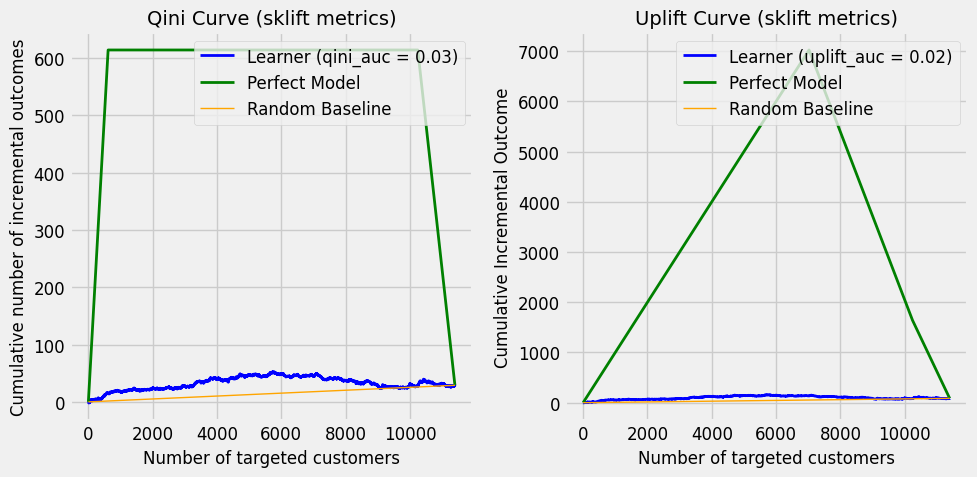

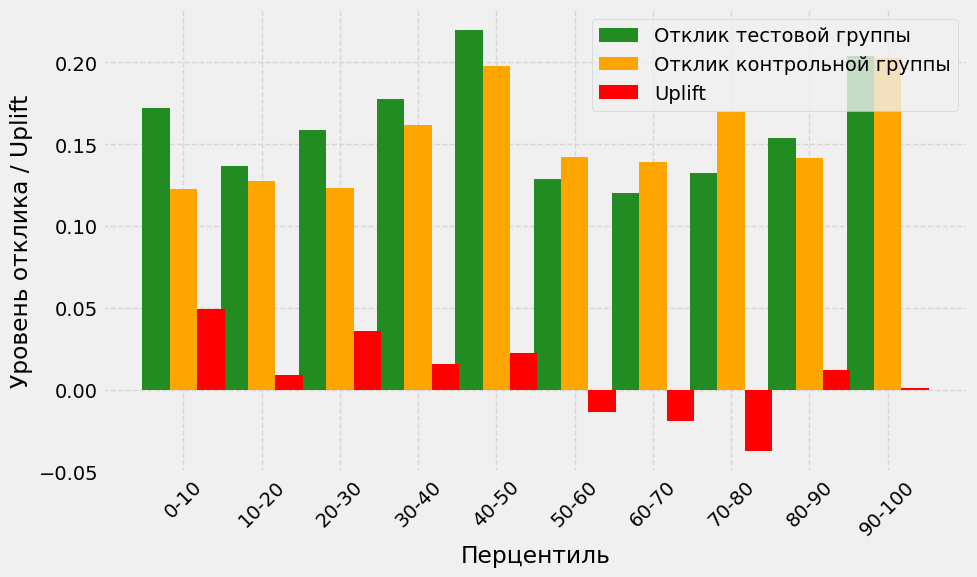

In [42]:
# построим графики вручную на основе данных из sklift (их и будем использовать в дальнейшем)
import matplotlib.pyplot as plt 
import utils

fig, axs = plt.subplots(1, 2, figsize=(10, 5))

utils.plot_qini_curve(y_test, pred_uplift, treat_test, axs=axs[0])
utils.plot_uplift_curve(y_test, pred_uplift, treat_test, axs=axs[1])

plt.tight_layout()
fig.savefig(f'{path_baseline}/qini_uplift_curves.png')

fig2 = utils.custom_uplift_by_percentile(y_test, pred_uplift, treat_test, kind='bar')
fig2.savefig(f'{path_baseline}/custom_uplift_by_percentile.png')

Графики из библиотеки causalml тоже выведем (но не совсем понятно как их интерпретировать)

Text(0.5, 0.98, 'CausalML uplift curve')

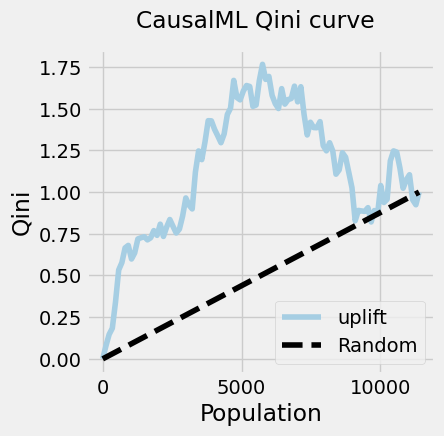

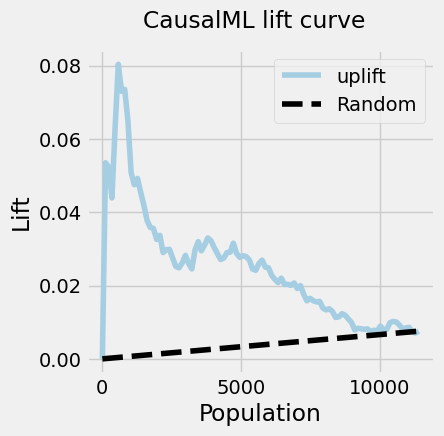

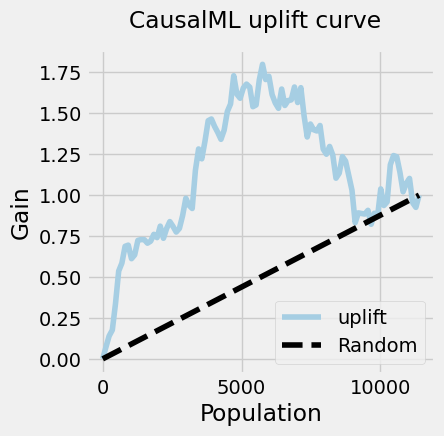

In [43]:
import matplotlib.pyplot as plt
from causalml.metrics import plot_qini, plot_lift, plot_gain

plot_qini(df, outcome_col='y', treatment_col='w', normalize=True, figsize=(4,4))
plt.suptitle('CausalML Qini curve')

plot_lift(df, outcome_col='y', treatment_col='w', figsize=(4,4))
plt.suptitle('CausalML lift curve')

plot_gain(df, outcome_col='y', treatment_col='w', normalize=True, figsize=(4,4))
plt.suptitle('CausalML uplift curve')

### Важность признаков baseline-модели
Рассмотрим важность признаков

,feature,importance
0,womens,0.717408
1,history,0.099406
2,mens,0.063209
3,zip_code,0.044036
4,newbie,0.042290
5,recency,0.019821
6,channel,0.011849
7,history_segment,0.001981


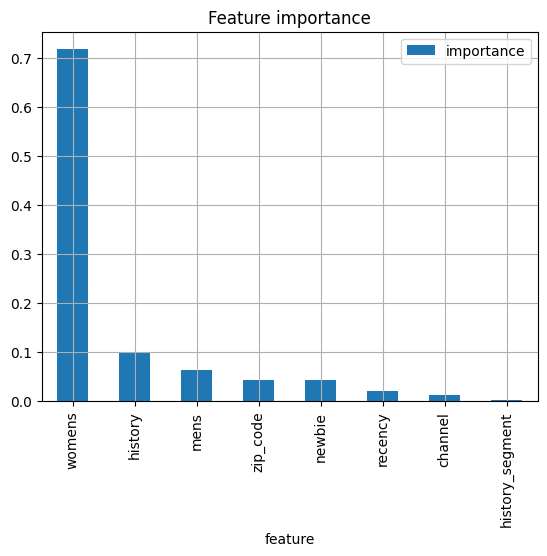

In [ ]:
from sklearn.ensemble import RandomForestRegressor
import matplotlib.pyplot as plt

plt.style.use('default')

fi = base_model.get_importance(
    X=X_test, 
    tau=pred_uplift, 
    features=features, 
    model_tau_feature=RandomForestRegressor(
        n_estimators=est_params['n_estimators'],
        max_depth=est_params['max_depth'],
        random_state=RANDOM_STATE),
    random_state=RANDOM_STATE
)
fi_df = pd.DataFrame.from_dict(fi[1]).reset_index()
fi_df.columns = ['feature', 'importance']
display(fi_df)

fi_df.plot.bar(x='feature', title='Feature importance')
plt.grid()

# save to file
plt.savefig('models/baseline/fi-score.png', bbox_inches='tight')

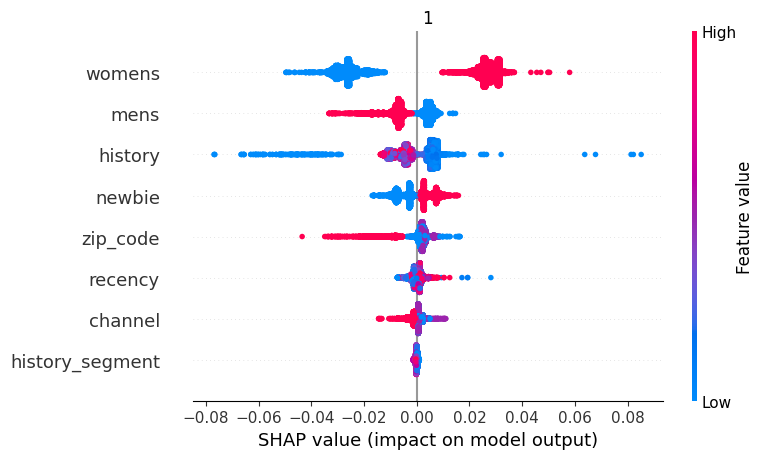

In [116]:
fig, axs = plt.subplots(1,1)
base_model.plot_shap_values(
    X=X_test, 
    tau=pred_uplift, 
    features=features,
    model_tau_feature=RandomForestRegressor(
        n_estimators=est_params['n_estimators'],
        max_depth=est_params['max_depth'],
        random_state=RANDOM_STATE)
)
fig.suptitle('Feature importance SHAP-values')
# save to file
fig.savefig('models/baseline/fi-shap.png', bbox_inches='tight')

#### Вывод
- наибольшее влияение оказал признак `womens` - видимо женщины (те кто покупал женские товары) более склонны к предложениям

### Вывод
- получены значения метрик, показывает, что baseline-модель все-таки смогла выделить клиентов склонных к предложениям, хоть и с невысокими значениями метрик
    - uplift_auc = 1.59%
    - qini_auc = 3.24%
    - uplift_at_30 = 3.17% 

### Логирование baseline-модели в MLflow
- сохраним результаты и артефакты обучения baseline-модели в MLflow 

Обертак для causalml модели, чтобы залогировать как pyfunc

In [9]:
import mlflow
import mlflow.pyfunc

class CausalMLTClassifierWrapper(mlflow.pyfunc.PythonModel):
    def load_context(self, context):
        self.model = mlflow.sklearn.load_model(context.artifacts["causalml_model"])

    def predict(self, context, model_input):
        return self.model.predict(model_input)

In [10]:
import mlflow, mlflow.sklearn, mlflow.pyfunc
import json
import os
import shutil
from dotenv import load_dotenv

TRACKING_SERVER_HOST = "127.0.0.1"
TRACKING_SERVER_PORT = 5000
MLFLOW_SERVER_URL = f'http://{TRACKING_SERVER_HOST}:{TRACKING_SERVER_PORT}'

load_dotenv()

mlflow.set_tracking_uri(MLFLOW_SERVER_URL)
mlflow.set_registry_uri(MLFLOW_SERVER_URL)

mlflow_client = mlflow.MlflowClient(mlflow.get_tracking_uri(), mlflow.get_registry_uri())

EXPERIMENT_NAME = "sprint-5-uplift-project-alex-khromenko" 
RUN_NAME = "stage-1-step-3-baseline-model"

experiment = mlflow.get_experiment_by_name(EXPERIMENT_NAME)
if not experiment:
    experiment_id = mlflow.create_experiment(EXPERIMENT_NAME)
else:
    experiment_id = experiment.experiment_id

ds_train = mlflow.data.from_pandas(df=X_train, name='train_dataset')
ds_val = mlflow.data.from_pandas(df=X_test, name='validation_dataset')

local_path = 'models/baseline'
with open(f'{local_path}/metrics.json', 'r', encoding='UTF-8') as f:
    metrics = json.load(f)

with open(f'{local_path}/params.json', 'r', encoding='UTF-8') as f:
    est_params = json.load(f)

local_model_path = f'{local_path}/tlearner'
if os.path.exists(local_model_path):
    shutil.rmtree(local_model_path)

with mlflow.start_run(run_name=RUN_NAME, description='Этап 3 - Построение baseline-модели' , experiment_id=experiment_id) as run:
    run_id = run.info.run_id
    print(f'run info: {run.info}')

    mlflow.log_input(ds_train, context='train')
    mlflow.log_input(ds_val, context='validate')
    
    mlflow.log_artifacts(artifact_path='model-perfomance', local_dir=local_path)
    mlflow.log_metrics(metrics=metrics)
    mlflow.log_params(est_params)
    
    mlflow.sklearn.save_model(sk_model=base_model, path=local_model_path)
    artifacts = {"causalml_model": local_model_path}

    mlflow.pyfunc.log_model(
        python_model=CausalMLTClassifierWrapper(),
        artifact_path='causalml-tlearner',
        artifacts=artifacts,
        input_example=X_train.head(),
        signature=mlflow.models.infer_signature(X_train, pred_uplift),
        pip_requirements='requirements.txt',
        metadata={
            'model-type': 'causalml.inference.meta.BaseTClassifier',
            'estimator': 'sklearn.ensemble.RandomForestClassifier'}
    )

### ---
run = mlflow_client.get_run(run_id=run_id)
print(f'run finish info: {run.info}')


/home/mle-user/mle_projects/sprint-5/mle-uplift-final-project-2025/.venv_mle-uplift-final-project-2025/lib/python3.10/site-packages/mlflow/data/digest_utils.py:26: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  string_columns = trimmed_df.columns[(df.applymap(type) == str).all(0)]
/home/mle-user/mle_projects/sprint-5/mle-uplift-final-project-2025/.venv_mle-uplift-final-project-2025/lib/python3.10/site-packages/mlflow/data/digest_utils.py:26: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  string_columns = trimmed_df.columns[(df.applymap(type) == str).all(0)]
/home/mle-user/mle_projects/sprint-5/mle-uplift-final-project-2025/.venv_mle-uplift-final-project-2025/lib/python3.10/site-packages/mlflow/data/pandas_dataset.py:116: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be 

run info: <RunInfo: artifact_uri='s3://s3-student-mle-20260306-f5465b0629-freetrack/Sprint-5/Project/16/4c85841557f247e78a23109e595af56a/artifacts', end_time=None, experiment_id='16', lifecycle_stage='active', run_id='4c85841557f247e78a23109e595af56a', run_name='stage-1-step-3-baseline-model', run_uuid='4c85841557f247e78a23109e595af56a', start_time=1784470751939, status='RUNNING', user_id='mle-user'>


/home/mle-user/mle_projects/sprint-5/mle-uplift-final-project-2025/.venv_mle-uplift-final-project-2025/lib/python3.10/site-packages/_distutils_hack/__init__.py:18: UserWarning: Distutils was imported before Setuptools, but importing Setuptools also replaces the `distutils` module in `sys.modules`. This may lead to undesirable behaviors or errors. To avoid these issues, avoid using distutils directly, ensure that setuptools is installed in the traditional way (e.g. not an editable install), and/or make sure that setuptools is always imported before distutils.
  warnings.warn(
/home/mle-user/mle_projects/sprint-5/mle-uplift-final-project-2025/.venv_mle-uplift-final-project-2025/lib/python3.10/site-packages/_distutils_hack/__init__.py:33: UserWarning: Setuptools is replacing distutils.
  warnings.warn("Setuptools is replacing distutils.")
/home/mle-user/mle_projects/sprint-5/mle-uplift-final-project-2025/.venv_mle-uplift-final-project-2025/lib/python3.10/site-packages/mlflow/models/signat

run finish info: <RunInfo: artifact_uri='s3://s3-student-mle-20260306-f5465b0629-freetrack/Sprint-5/Project/16/4c85841557f247e78a23109e595af56a/artifacts', end_time=1784470755984, experiment_id='16', lifecycle_stage='active', run_id='4c85841557f247e78a23109e595af56a', run_name='stage-1-step-3-baseline-model', run_uuid='4c85841557f247e78a23109e595af56a', start_time=1784470751939, status='FINISHED', user_id='mle-user'>


run finish info: <RunInfo: artifact_uri='s3://s3-student-mle-20260306-f5465b0629-freetrack/Sprint-5/Project/16/4c85841557f247e78a23109e595af56a/artifacts', end_time=1784470755984, experiment_id='16', lifecycle_stage='active', run_id='4c85841557f247e78a23109e595af56a', run_name='stage-1-step-3-baseline-model', run_uuid='4c85841557f247e78a23109e595af56a', start_time=1784470751939, status='FINISHED', user_id='mle-user'>

Проверим, что модель можно загрузить и использовать

In [11]:
import mlflow
import pandas as pd

run_id = "4c85841557f247e78a23109e595af56a"
model_uri = f"s3://s3-student-mle-20260306-f5465b0629-freetrack/Sprint-5/Project/16/{run_id}/artifacts/causalml-tlearner"

loaded_model = mlflow.pyfunc.load_model(model_uri)

test_predictions = loaded_model.predict(X_test.head(5))
test_predictions


2026/07/19 14:20:48 WARNING mlflow.pyfunc: Detected one or more mismatches between the model's dependencies and the current Python environment:
 - cloudpickle (current: 2.2.1, required: cloudpickle==3.0.0)
 - numpy (current: 1.26.4, required: numpy==2.2.6)
 - scikit-learn (current: 1.5.2, required: scikit-learn==1.6.1)
To fix the mismatches, call `mlflow.pyfunc.get_model_dependencies(model_uri)` to fetch the model's environment and install dependencies using the resulting environment file.
/home/mle-user/mle_projects/sprint-5/mle-uplift-final-project-2025/.venv_mle-uplift-final-project-2025/lib/python3.10/site-packages/sklearn/base.py:486: UserWarning: X has feature names, but RandomForestClassifier was fitted without feature names
  warnings.warn(
/home/mle-user/mle_projects/sprint-5/mle-uplift-final-project-2025/.venv_mle-uplift-final-project-2025/lib/python3.10/site-packages/sklearn/base.py:486: UserWarning: X has feature names, but RandomForestClassifier was fitted without feature 

array([[ 0.05861574],
       [-0.02368623],
       [-0.01451038],
       [-0.03183975],
       [-0.00547876]])

### Обучение 2 моделей 

In [7]:
import json

local_path = 'models/baseline'
with open(f'{local_path}/params.json', 'r', encoding='UTF-8') as f:
    est_params = json.load(f)
est_params

{'n_estimators': 100, 'max_depth': 6, 'random_state': 43}

#### Обучение модели 1

Рассмотрим модель uplift-деревьев UpliftRandomForestClassifier из библиотеки causalml 

In [8]:
from causalml.inference.tree import UpliftRandomForestClassifier

treatment_mapping = {
    0: 'control',
    1: 'treatment'
}
treat_train_mapped = pd.Series(treat_train).map(treatment_mapping)
treat_test_mapped = pd.Series(treat_test).map(treatment_mapping)

uplift_tree_model = UpliftRandomForestClassifier(
    n_estimators=est_params['n_estimators'],
    max_depth=est_params['max_depth'],
    random_state=est_params['random_state'],
    control_name='control'
)
uplift_tree_model.fit(X=X_train.values, treatment=treat_train_mapped, y=y_train)

##### Получение метрик по модели 1

uplift_tree_model metrics = {'uplift_auc': 0.0204, 'qini_auc': 0.0422, 'uplift_at_30': 0.0336}


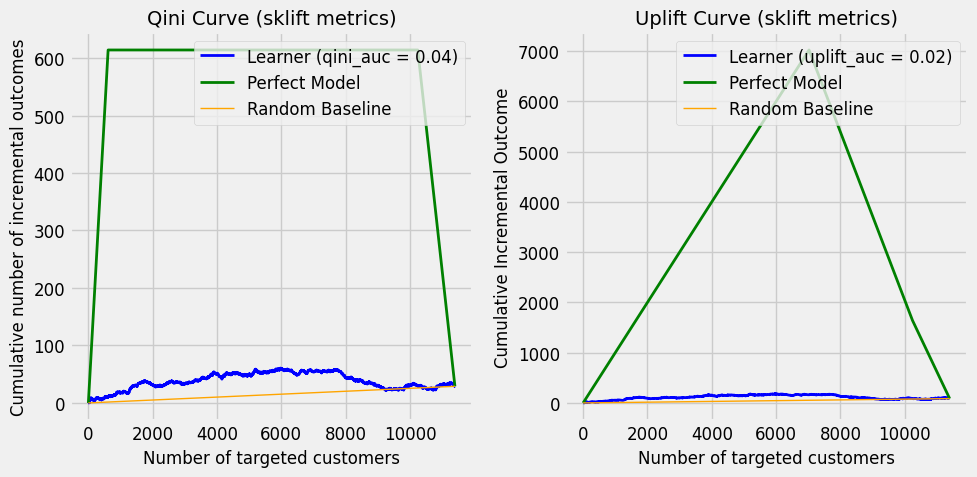

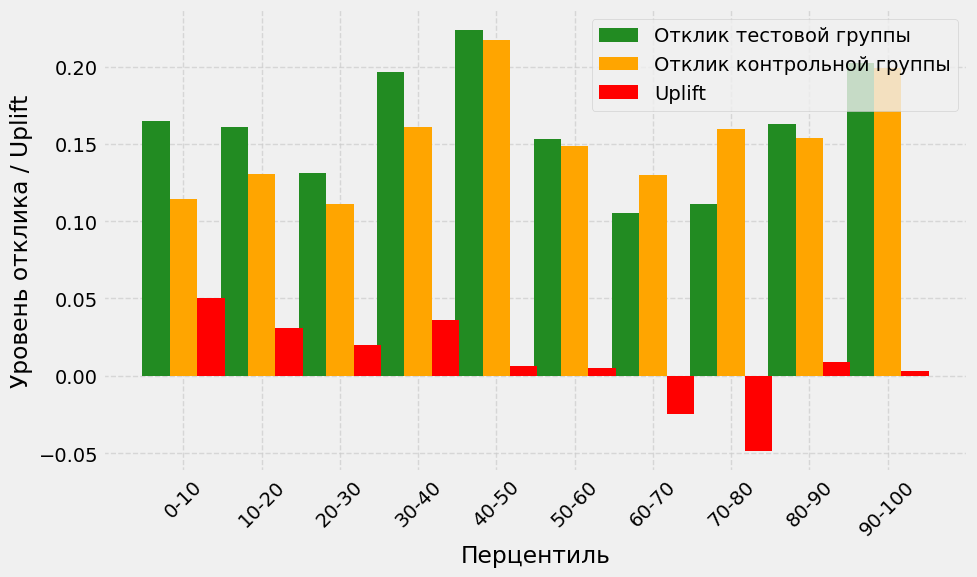

In [35]:
import utils

model_path = 'models/uplift_tree_model'

uplift_tree_pred = uplift_tree_model.predict(X_test.values, full_output=False).squeeze()

metrics = utils.calc_and_save_uplift_metrics(y_test, uplift_tree_pred, treat_test, model_path)
print(f'uplift_tree_model metrics = {metrics}')

utils.plot_and_save_uplift_curves(y_test, uplift_tree_pred, treat_test, model_path)

##### Важность признаков модели 1

,feature,importance
3,mens,0.321072
2,history,0.257871
0,recency,0.153776
5,zip_code,0.077528
7,channel,0.068562
1,history_segment,0.046336
6,newbie,0.044261
4,womens,0.030595


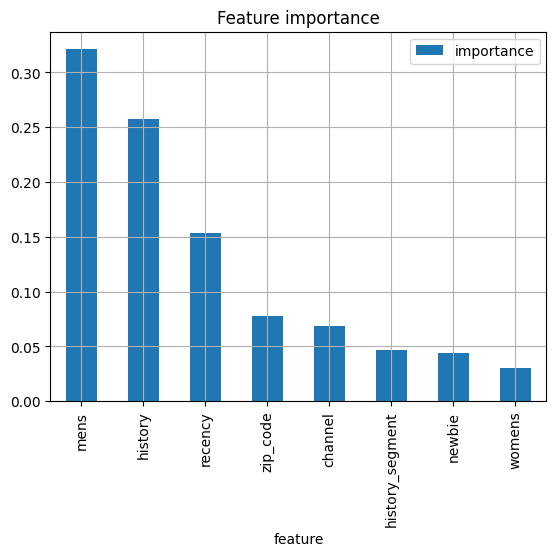

In [ ]:
import matplotlib.pyplot as plt
plt.style.use('default')

fi = uplift_tree_model.feature_importances_
fi_df = pd.DataFrame(fi, index=features).reset_index()
fi_df.columns = ['feature', 'importance']
fi_df = fi_df.sort_values(by=['importance'], ascending=False)
display(fi_df)

fi_df.plot.bar(x='feature', title='Feature importance')
plt.grid()

# save to file
plt.savefig(f'{model_path}/fi-score.png', bbox_inches='tight')

##### Результат по модели 1
- модель 1 (UpliftRandomForestClassifier) показал улучшение по всем метрикам
    - uplift_auc = 0.0204 
        - рост на 28,30% относительно baseline модели (у baseline uplift_auc = 0.0159)
    - qini_auc = 0.0422
        - рост на 30,25% относительно baseline модели (у baseline qini_auc = 0.0324)
    - uplift_at_30 = 0.0336 
        - рост на 5,99% относительно baseline модели (у baseline uplift_at_30 = 0.0317)

- важность признаков отличается от baseline
    - на первое место вышли "мужчины" `mens` (в отличие от "женщин" у baseline)
    - history получил гораздо больший вес

- вероятно, модель UpliftRandomForestClassifier как более сложная и специализированная, смогла обнаружить более тонкие зависимости при формировании uplift-деревьев 

#### Обучение модели 2

Рассмотрим модель R-learner - BaseRClassifier из библиотеки causalml с тремя базовыми моделими на основе деревьев RandomForestClassifier

In [32]:
from causalml.inference.meta import BaseRLearner
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor

est_outcome = RandomForestRegressor(
    n_estimators=est_params['n_estimators'],
    max_depth=est_params['max_depth'],
    random_state=est_params['random_state'])

est_effect = RandomForestRegressor(
    n_estimators=est_params['n_estimators'],
    max_depth=est_params['max_depth'],
    random_state=est_params['random_state'])

est_prop = RandomForestClassifier(
    n_estimators=est_params['n_estimators'],
    max_depth=est_params['max_depth'],
    random_state=est_params['random_state'])

r_learner_model = BaseRLearner(
    outcome_learner=est_outcome,
    effect_learner=est_effect,
    propensity_learner=est_prop,
    control_name=0,
    random_state=est_params['random_state']
    )

r_learner_model.fit(X=X_train.values, treatment=treat_train, y=y_train) #p=?

##### Получение метрик по модели 2

r_learner_model metrics = {'uplift_auc': 0.0178, 'qini_auc': 0.0369, 'uplift_at_30': 0.0346}


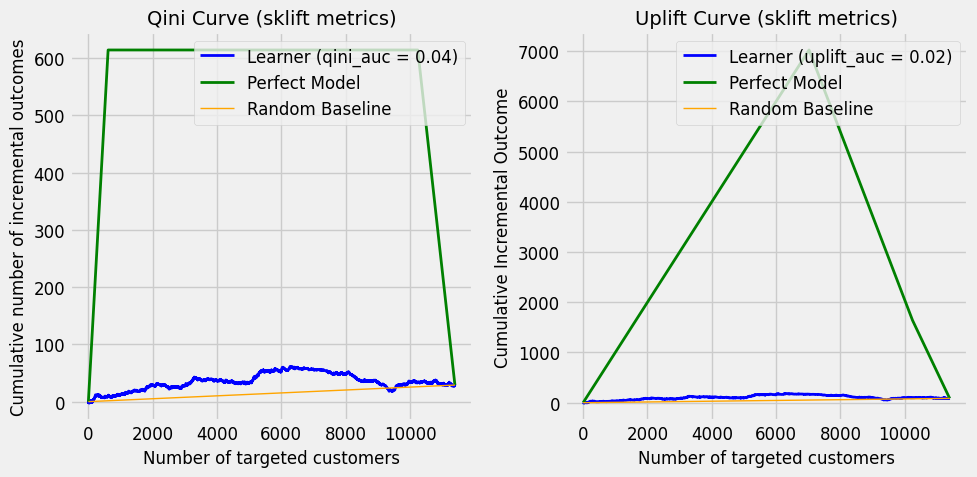

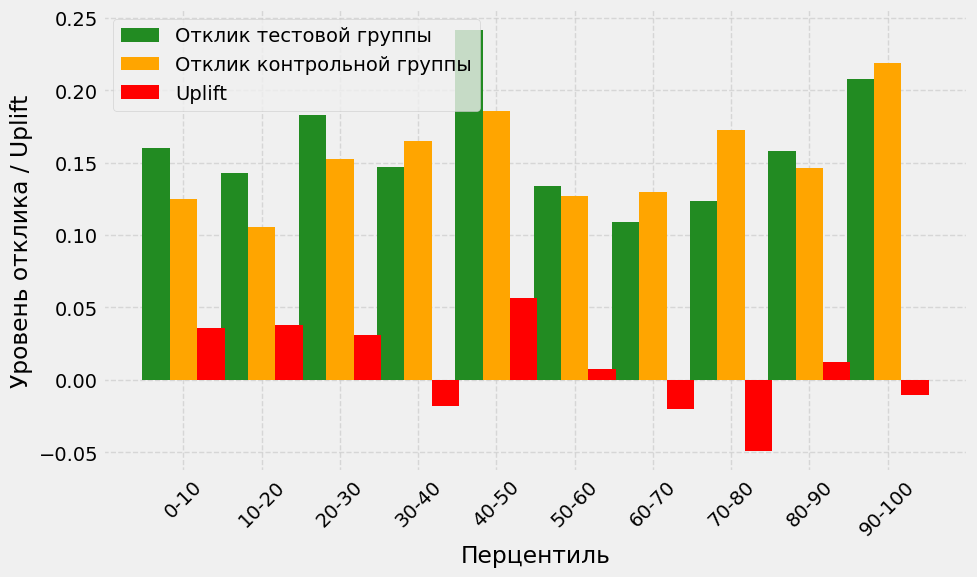

In [33]:
import utils

model_path = 'models/r_learner_model'

r_learner_pred = r_learner_model.predict(X_test.values).squeeze()

metrics = utils.calc_and_save_uplift_metrics(y_test, r_learner_pred, treat_test, model_path)
print(f'r_learner_model metrics = {metrics}')

utils.plot_and_save_uplift_curves(y_test, r_learner_pred, treat_test, model_path)

##### Важность признаков модели 2

,feature,importance
0,mens,0.821556
1,history,0.108447
2,recency,0.028796
3,newbie,0.023940
4,zip_code,0.009270
5,womens,0.006027
6,channel,0.001631
7,history_segment,0.000333


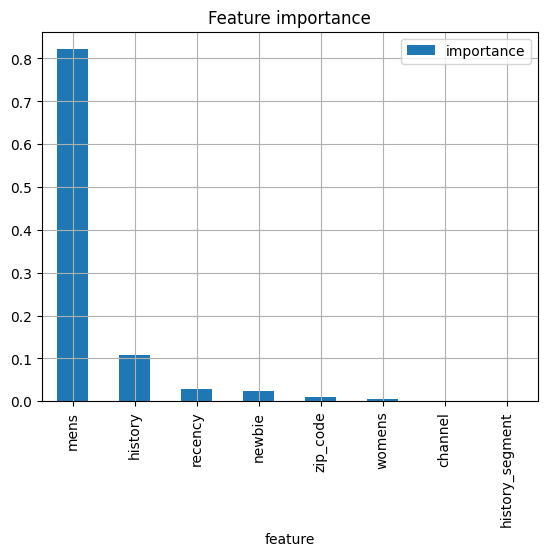

In [75]:
import matplotlib.pyplot as plt
plt.style.use('default')

fi = r_learner_model.get_importance(
    X=X_test, 
    tau=r_learner_pred, 
    features=features, 
    model_tau_feature=RandomForestRegressor(
        n_estimators=est_params['n_estimators'],
        max_depth=est_params['max_depth'],
        random_state=RANDOM_STATE),
    random_state=RANDOM_STATE
)
fi_df = pd.DataFrame.from_dict(fi[1]).reset_index()
fi_df.columns = ['feature', 'importance']
#fi_df = fi_df.sort_values(by=['importance'], ascending=False)
display(fi_df)

fi_df.plot.bar(x='feature', title='Feature importance')
plt.grid()

# save to file
plt.savefig(f'{model_path}/fi-score.png', bbox_inches='tight')

##### Результат по модели 2
- модель 2 (BaseRLearner) показал улучшение по всем метрикам
    - uplift_auc = 0.0178
        - рост на 11,95% относительно baseline модели (у baseline uplift_auc = 0.0159)
    - qini_auc = 0.0369
        - рост на 13,89% относительно baseline модели (у baseline qini_auc = 0.0324)
    - uplift_at_30 = 0.0346
        - рост на 9,15% относительно baseline модели (у baseline uplift_at_30 = 0.0317)

- важность признаков очень похожа от baseline
    - только вместо "женщин" на первом месте оказались "мужчины" `mens` - эти признаки сильно коррелирует, так что это ожидаемое следствие

- вероятно, модель BaseRLearner с моделями RandomForestRegressor как более сложная и специализированная двухэтапная модель разделения эффекта в группах, смогла обнаружить более тонкие зависимости при формировании uplift эффекта (CATE)

### Сводные результаты по 3-м моделям

,uplift_auc,qini_auc,uplift_at_30,uplift_auc_delta,qini_auc_delta,uplift_at_30_delta
baseline,0.0159,0.0324,0.0317,0.000000,0.000000,0.000000
uplift_tree_model,0.0204,0.0422,0.0336,0.283019,0.302469,0.059937
r_learner_model,0.0178,0.0369,0.0346,0.119497,0.138889,0.091483


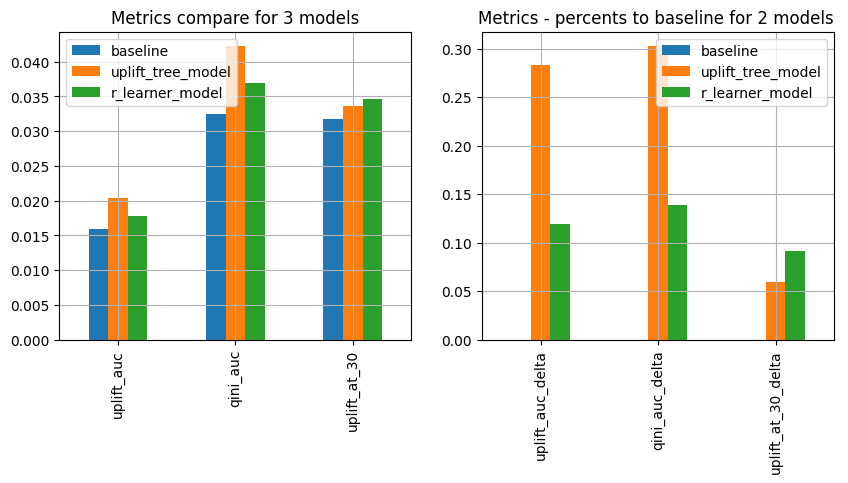

In [126]:
import json
with open('models/baseline/metrics.json', 'r', encoding='UTF-8') as f:
    metrics1 = json.load(f)
with open('models/uplift_tree_model/metrics.json', 'r', encoding='UTF-8') as f:
    metrics2 = json.load(f)
with open('models/r_learner_model/metrics.json', 'r', encoding='UTF-8') as f:
    metrics3 = json.load(f)

joint_metrics = pd.DataFrame.from_dict([metrics1, metrics2, metrics3])
joint_metrics.index = ['baseline', 'uplift_tree_model', 'r_learner_model']

joint_metrics['uplift_auc_delta'] = joint_metrics.apply(lambda row: (row['uplift_auc']-metrics1['uplift_auc'])/metrics1['uplift_auc'], axis=1)
joint_metrics['qini_auc_delta'] = joint_metrics.apply(lambda row: (row['qini_auc']-metrics1['qini_auc'])/metrics1['qini_auc'], axis=1)
joint_metrics['uplift_at_30_delta'] = joint_metrics.apply(lambda row: (row['uplift_at_30']-metrics1['uplift_at_30'])/metrics1['uplift_at_30'], axis=1)

joint_metrics.to_csv('models/joint_metrics.csv')

display(joint_metrics)

fig, axs = plt.subplots(1,2, figsize=(10,4))
joint_metrics[['uplift_auc', 'qini_auc', 'uplift_at_30']].T.plot.bar(grid='True', title='Metrics compare for 3 models', ax=axs[0])
joint_metrics[['uplift_auc_delta', 'qini_auc_delta', 'uplift_at_30_delta']].T.plot.bar(grid='True', title='Metrics - percents to baseline for 2 models ', ax=axs[1])
fig.savefig('models/metrics_compare.png', bbox_inches='tight')


#### Проинтерпретируйте полученные результаты и обоснуйте выбор 1 модели в этой ячейке
--
Выводы

- baseline-модель BaseTClassifier на основе RandomForrestClassier показала себя достаточно хорошо, сразу выявив минимальный uplift-эффект, что подтверждает правильность модели с деревьями как надежной baseline-модель
- при этом специализированная uplift-модель - UpliftRandomForestClassifier (тоже на основе деревьев) смогла улучшить 
    - показатель uplift_auc на 28% по сравнению с baseline
    - показатель  qini_auc на 30% по сравнению с baseline
    - показатель  uplift_at_30 на 6% по сравнению с baseline
- специализированная модель R-learner 
    - тоже улучшила метрики uplift_auc, qini_auc - но меньше чем uplift-модель
    - однако по показателю uplift_at_30 эта модель дала лучший результат, на 9% лучше чем baseline

- причины улучшения показателей могли быть в том, что продвинутые модели применяют более сложные алгоритмы для выявления именно uplift эффекта, в отличие от простой baseline модели, также возможно настройки моделей по умолчанию различаются, что позволяет некоторым моделям более тонко выявлять зависимости


#### Логирование дополнительных моделей в MLflow
- сохраним результаты и артефакты обучения 2-х дополнительных моделей в MLflow 

##### Логирование модели 1

Обертак для causalml модели, чтобы залогировать как pyfunc

In [15]:
import mlflow
import mlflow.pyfunc

class CausalMLUpliftTreeWrapper(mlflow.pyfunc.PythonModel):
    def load_context(self, context):
        self.model = mlflow.sklearn.load_model(context.artifacts["causalml_model"])

    def predict(self, context, model_input):
        return self.model.predict(model_input)

In [18]:
import mlflow, mlflow.sklearn, mlflow.pyfunc
import json
import os
import shutil
from dotenv import load_dotenv

TRACKING_SERVER_HOST = "127.0.0.1"
TRACKING_SERVER_PORT = 5000
MLFLOW_SERVER_URL = f'http://{TRACKING_SERVER_HOST}:{TRACKING_SERVER_PORT}'

load_dotenv()

mlflow.set_tracking_uri(MLFLOW_SERVER_URL)
mlflow.set_registry_uri(MLFLOW_SERVER_URL)

mlflow_client = mlflow.MlflowClient(mlflow.get_tracking_uri(), mlflow.get_registry_uri())

EXPERIMENT_NAME = "sprint-5-uplift-project-alex-khromenko" 
RUN_NAME = "stage-1-step-3-model-1-reference"

experiment = mlflow.get_experiment_by_name(EXPERIMENT_NAME)
if not experiment:
    experiment_id = mlflow.create_experiment(EXPERIMENT_NAME)
else:
    experiment_id = experiment.experiment_id

local_path = 'models/uplift_tree_model'
with open(f'{local_path}/metrics.json', 'r', encoding='UTF-8') as f:
    metrics = json.load(f)

local_model_path = f'{local_path}/uplift-rf'
if os.path.exists(local_model_path):
    shutil.rmtree(local_model_path)

ds_train = mlflow.data.from_pandas(df=X_train, name='train_dataset')
ds_val = mlflow.data.from_pandas(df=X_test, name='validation_dataset')

with mlflow.start_run(run_name=RUN_NAME, description='Этап 3 - Дополнительная модель - 1' , experiment_id=experiment_id) as run:
    run_id = run.info.run_id
    print(f'run info: {run.info}')

    mlflow.log_input(ds_train, context='train')
    mlflow.log_input(ds_val, context='validate')
    
    mlflow.log_artifacts(artifact_path='model-perfomance', local_dir=local_path)
    mlflow.log_metrics(metrics=metrics)
    mlflow.log_params(est_params)
    
    mlflow.sklearn.save_model(sk_model=uplift_tree_model, path=local_model_path)
    artifacts = {"causalml_model": local_model_path}

    mlflow.pyfunc.log_model(
        python_model=CausalMLUpliftTreeWrapper(),
        artifact_path='causalml_uplift_tree',
        artifacts=artifacts,
        input_example=X_train.head(),
        signature=mlflow.models.infer_signature(X_train, uplift_tree_pred),
        pip_requirements='requirements.txt',
        metadata={
            'model-type': 'causalml.inference.tree.UpliftRandomForestClassifier',
            'estimator': '-'}
    )

### ---
run = mlflow_client.get_run(run_id=run_id)
print(f'run finish info: {run.info}')


/home/mle-user/mle_projects/sprint-5/mle-uplift-final-project-2025/.venv_mle-uplift-final-project-2025/lib/python3.10/site-packages/mlflow/data/digest_utils.py:26: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  string_columns = trimmed_df.columns[(df.applymap(type) == str).all(0)]
/home/mle-user/mle_projects/sprint-5/mle-uplift-final-project-2025/.venv_mle-uplift-final-project-2025/lib/python3.10/site-packages/mlflow/data/digest_utils.py:26: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  string_columns = trimmed_df.columns[(df.applymap(type) == str).all(0)]
/home/mle-user/mle_projects/sprint-5/mle-uplift-final-project-2025/.venv_mle-uplift-final-project-2025/lib/python3.10/site-packages/mlflow/data/pandas_dataset.py:116: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be 

run info: <RunInfo: artifact_uri='s3://s3-student-mle-20260306-f5465b0629-freetrack/Sprint-5/Project/16/d8499ca9fca047b0ac94452fdd469de3/artifacts', end_time=None, experiment_id='16', lifecycle_stage='active', run_id='d8499ca9fca047b0ac94452fdd469de3', run_name='stage-1-step-3-model-1-reference', run_uuid='d8499ca9fca047b0ac94452fdd469de3', start_time=1784472165486, status='RUNNING', user_id='mle-user'>


/home/mle-user/mle_projects/sprint-5/mle-uplift-final-project-2025/.venv_mle-uplift-final-project-2025/lib/python3.10/site-packages/_distutils_hack/__init__.py:18: UserWarning: Distutils was imported before Setuptools, but importing Setuptools also replaces the `distutils` module in `sys.modules`. This may lead to undesirable behaviors or errors. To avoid these issues, avoid using distutils directly, ensure that setuptools is installed in the traditional way (e.g. not an editable install), and/or make sure that setuptools is always imported before distutils.
  warnings.warn(
/home/mle-user/mle_projects/sprint-5/mle-uplift-final-project-2025/.venv_mle-uplift-final-project-2025/lib/python3.10/site-packages/_distutils_hack/__init__.py:33: UserWarning: Setuptools is replacing distutils.
  warnings.warn("Setuptools is replacing distutils.")
/home/mle-user/mle_projects/sprint-5/mle-uplift-final-project-2025/.venv_mle-uplift-final-project-2025/lib/python3.10/site-packages/mlflow/models/signat

run finish info: <RunInfo: artifact_uri='s3://s3-student-mle-20260306-f5465b0629-freetrack/Sprint-5/Project/16/d8499ca9fca047b0ac94452fdd469de3/artifacts', end_time=1784472170055, experiment_id='16', lifecycle_stage='active', run_id='d8499ca9fca047b0ac94452fdd469de3', run_name='stage-1-step-3-model-1-reference', run_uuid='d8499ca9fca047b0ac94452fdd469de3', start_time=1784472165486, status='FINISHED', user_id='mle-user'>


<RunInfo: artifact_uri='s3://s3-student-mle-20260306-f5465b0629-freetrack/Sprint-5/Project/16/d8499ca9fca047b0ac94452fdd469de3/artifacts', end_time=1784472170055, experiment_id='16', lifecycle_stage='active', run_id='d8499ca9fca047b0ac94452fdd469de3', run_name='stage-1-step-3-model-1-reference', run_uuid='d8499ca9fca047b0ac94452fdd469de3', start_time=1784472165486, status='FINISHED', user_id='mle-user'>

##### Логирование модели 2

In [ ]:
import mlflow
import mlflow.pyfunc

class CausalMLRLearnerWrapper(mlflow.pyfunc.PythonModel):
    def load_context(self, context):
        self.model = mlflow.sklearn.load_model(context.artifacts["causalml_model"])

    def predict(self, context, model_input):
        return self.model.predict(model_input)

In [21]:
import mlflow, mlflow.sklearn, mlflow.pyfunc
import json
import os
import shutil
from dotenv import load_dotenv

TRACKING_SERVER_HOST = "127.0.0.1"
TRACKING_SERVER_PORT = 5000
MLFLOW_SERVER_URL = f'http://{TRACKING_SERVER_HOST}:{TRACKING_SERVER_PORT}'

load_dotenv()

mlflow.set_tracking_uri(MLFLOW_SERVER_URL)
mlflow.set_registry_uri(MLFLOW_SERVER_URL)

mlflow_client = mlflow.MlflowClient(mlflow.get_tracking_uri(), mlflow.get_registry_uri())

EXPERIMENT_NAME = "sprint-5-uplift-project-alex-khromenko" 
RUN_NAME = "stage-1-step-3-model-2-reference"

experiment = mlflow.get_experiment_by_name(EXPERIMENT_NAME)
if not experiment:
    experiment_id = mlflow.create_experiment(EXPERIMENT_NAME)
else:
    experiment_id = experiment.experiment_id

local_path = 'models/r_learner_model'
with open(f'{local_path}/metrics.json', 'r', encoding='UTF-8') as f:
    metrics = json.load(f)

local_model_path = f'{local_path}/rlearner'
if os.path.exists(local_model_path):
    shutil.rmtree(local_model_path)

ds_train = mlflow.data.from_pandas(df=X_train, name='train_dataset')
ds_val = mlflow.data.from_pandas(df=X_test, name='validation_dataset')

with mlflow.start_run(run_name=RUN_NAME, description='Этап 3 - Дополнительная модель - 2' , experiment_id=experiment_id) as run:
    run_id = run.info.run_id
    print(f'run info: {run.info}')

    mlflow.log_input(ds_train, context='train')
    mlflow.log_input(ds_val, context='validate')
    
    mlflow.log_artifacts(artifact_path='model-perfomance', local_dir=local_path)
    mlflow.log_metrics(metrics=metrics)
    mlflow.log_params(est_params)
    
    mlflow.sklearn.save_model(sk_model=r_learner_model, path=local_model_path)
    artifacts = {"causalml_model": local_model_path}

    mlflow.pyfunc.log_model(
        python_model=CausalMLUpliftTreeWrapper(),
        artifact_path='causalml_rlearner',
        artifacts=artifacts,
        input_example=X_train.head(),
        signature=mlflow.models.infer_signature(X_train, r_learner_pred),
        pip_requirements='requirements.txt',
        metadata={
            'model-type': 'causalml.inference.meta.BaseRLearner',
            'estimator': '[sklearn.ensemble.RandomForestClassifier, sklearn.ensemble.RandomForestRegressor]'}
    )

### ---
run = mlflow_client.get_run(run_id=run_id)
print(f'run finish info: {run.info}')


/home/mle-user/mle_projects/sprint-5/mle-uplift-final-project-2025/.venv_mle-uplift-final-project-2025/lib/python3.10/site-packages/mlflow/data/digest_utils.py:26: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  string_columns = trimmed_df.columns[(df.applymap(type) == str).all(0)]
/home/mle-user/mle_projects/sprint-5/mle-uplift-final-project-2025/.venv_mle-uplift-final-project-2025/lib/python3.10/site-packages/mlflow/data/digest_utils.py:26: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  string_columns = trimmed_df.columns[(df.applymap(type) == str).all(0)]
/home/mle-user/mle_projects/sprint-5/mle-uplift-final-project-2025/.venv_mle-uplift-final-project-2025/lib/python3.10/site-packages/mlflow/data/pandas_dataset.py:116: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be 

run info: <RunInfo: artifact_uri='s3://s3-student-mle-20260306-f5465b0629-freetrack/Sprint-5/Project/16/1516534435cf443e9e64c0293e353a44/artifacts', end_time=None, experiment_id='16', lifecycle_stage='active', run_id='1516534435cf443e9e64c0293e353a44', run_name='stage-1-step-3-model-2-reference', run_uuid='1516534435cf443e9e64c0293e353a44', start_time=1784472309033, status='RUNNING', user_id='mle-user'>


/home/mle-user/mle_projects/sprint-5/mle-uplift-final-project-2025/.venv_mle-uplift-final-project-2025/lib/python3.10/site-packages/_distutils_hack/__init__.py:18: UserWarning: Distutils was imported before Setuptools, but importing Setuptools also replaces the `distutils` module in `sys.modules`. This may lead to undesirable behaviors or errors. To avoid these issues, avoid using distutils directly, ensure that setuptools is installed in the traditional way (e.g. not an editable install), and/or make sure that setuptools is always imported before distutils.
  warnings.warn(
/home/mle-user/mle_projects/sprint-5/mle-uplift-final-project-2025/.venv_mle-uplift-final-project-2025/lib/python3.10/site-packages/_distutils_hack/__init__.py:33: UserWarning: Setuptools is replacing distutils.
  warnings.warn("Setuptools is replacing distutils.")
/home/mle-user/mle_projects/sprint-5/mle-uplift-final-project-2025/.venv_mle-uplift-final-project-2025/lib/python3.10/site-packages/mlflow/models/signat

run finish info: <RunInfo: artifact_uri='s3://s3-student-mle-20260306-f5465b0629-freetrack/Sprint-5/Project/16/1516534435cf443e9e64c0293e353a44/artifacts', end_time=1784472313448, experiment_id='16', lifecycle_stage='active', run_id='1516534435cf443e9e64c0293e353a44', run_name='stage-1-step-3-model-2-reference', run_uuid='1516534435cf443e9e64c0293e353a44', start_time=1784472309033, status='FINISHED', user_id='mle-user'>


<RunInfo: artifact_uri='s3://s3-student-mle-20260306-f5465b0629-freetrack/Sprint-5/Project/16/1516534435cf443e9e64c0293e353a44/artifacts', end_time=1784472313448, experiment_id='16', lifecycle_stage='active', run_id='1516534435cf443e9e64c0293e353a44', run_name='stage-1-step-3-model-2-reference', run_uuid='1516534435cf443e9e64c0293e353a44', start_time=1784472309033, status='FINISHED', user_id='mle-user'>

##### Логирование сводных результатов

In [22]:
import mlflow
from dotenv import load_dotenv

TRACKING_SERVER_HOST = "127.0.0.1"
TRACKING_SERVER_PORT = 5000
MLFLOW_SERVER_URL = f'http://{TRACKING_SERVER_HOST}:{TRACKING_SERVER_PORT}'

load_dotenv()

mlflow.set_tracking_uri(MLFLOW_SERVER_URL)
mlflow.set_registry_uri(MLFLOW_SERVER_URL)

mlflow_client = mlflow.MlflowClient(mlflow.get_tracking_uri(), mlflow.get_registry_uri())

EXPERIMENT_NAME = "sprint-5-uplift-project-alex-khromenko" 
RUN_NAME = "stage-1-step-3-models-compare"

experiment = mlflow.get_experiment_by_name(EXPERIMENT_NAME)
if not experiment:
    experiment_id = mlflow.create_experiment(EXPERIMENT_NAME)
else:
    experiment_id = experiment.experiment_id

with mlflow.start_run(run_name=RUN_NAME, description='Этап 3 - Сравнение 3-х моделей' , experiment_id=experiment_id) as run:
    run_id = run.info.run_id
    print(f'run info: {run.info}')

    mlflow.log_artifact(artifact_path='model-perfomance', local_path='models/joint_metrics.csv')
    mlflow.log_artifact(artifact_path='model-perfomance', local_path='models/metrics_compare.png')

### ---
run = mlflow_client.get_run(run_id=run_id)
print(f'run finish info: {run.info}')


run info: <RunInfo: artifact_uri='s3://s3-student-mle-20260306-f5465b0629-freetrack/Sprint-5/Project/16/0541094132a74eda8dee910fc1c6e9c0/artifacts', end_time=None, experiment_id='16', lifecycle_stage='active', run_id='0541094132a74eda8dee910fc1c6e9c0', run_name='stage-1-step-3-models-compare', run_uuid='0541094132a74eda8dee910fc1c6e9c0', start_time=1784472356929, status='RUNNING', user_id='mle-user'>
run finish info: <RunInfo: artifact_uri='s3://s3-student-mle-20260306-f5465b0629-freetrack/Sprint-5/Project/16/0541094132a74eda8dee910fc1c6e9c0/artifacts', end_time=1784472357005, experiment_id='16', lifecycle_stage='active', run_id='0541094132a74eda8dee910fc1c6e9c0', run_name='stage-1-step-3-models-compare', run_uuid='0541094132a74eda8dee910fc1c6e9c0', start_time=1784472356929, status='FINISHED', user_id='mle-user'>


<RunInfo: artifact_uri='s3://s3-student-mle-20260306-f5465b0629-freetrack/Sprint-5/Project/16/0541094132a74eda8dee910fc1c6e9c0/artifacts', end_time=1784472357005, experiment_id='16', lifecycle_stage='active', run_id='0541094132a74eda8dee910fc1c6e9c0', run_name='stage-1-step-3-models-compare', run_uuid='0541094132a74eda8dee910fc1c6e9c0', start_time=1784472356929, status='FINISHED', user_id='mle-user'>

# Часть 2

## Этап 1
### Улучшите бейзлайн выбранной модели

Подготовим разбиение данных - выполнить код из данного раздела - <a href="#data-train-test-split">Часть 1 - Этап 3 - Разбиение выборки на тренировочную и тестовую</a>

- В 1-ой части модель R-learner показала лучший результат по метрике uplift@30 (0.034)
- Рассмотрим, что можно сделать с этой моделью для улучшения

#### Использование более сложных базовых моделей

Подготовим категорийные данные

In [24]:
features = ['recency', 'history_segment', 'history', 'mens', 'womens', 'zip_code', 'newbie', 'channel']
cat_features = ['history_segment', 'mens', 'womens', 'zip_code', 'newbie', 'channel']
cat_features_indices = [X_train.columns.get_loc(col) for col in cat_features]

X_train_cat = X_train.copy()
X_train_cat[cat_features] = X_train[cat_features].astype(str)

X_test_cat = X_test.copy()
X_test_cat[cat_features] = X_test[cat_features].astype(str)

Базовые параметры

In [25]:
est_params = {
    'n_estimators': 100,
    'max_depth': 6,
    'learning_rate':  0.03,
    'verbose': False,
    'random_state': RANDOM_STATE
}


##### CatBoostClassifier
- попробуем CatBoostClassifier в качестве базовой модели R-Learner

In [30]:
from causalml.inference.meta import BaseRLearner
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
import matplotlib.pyplot as plt
import utils
from catboost import CatBoostClassifier, CatBoostRegressor

est_outcome = CatBoostClassifier(cat_features=cat_features_indices, **est_params)
est_effect = CatBoostRegressor(cat_features=cat_features_indices, **est_params)
est_prop = CatBoostClassifier(cat_features=cat_features_indices, **est_params)

r_learner_model = BaseRLearner(
    n_fold=5,
    outcome_learner=est_outcome,
    effect_learner=est_effect,
    propensity_learner=est_prop,
    control_name=0,
    random_state=est_params['random_state']
    )

r_learner_model.fit(X=X_train_cat, treatment=treat_train, y=y_train)

# predict
r_learner_pred = r_learner_model.predict(X_test_cat).squeeze()


# metrics
model_1_path = 'model_improvement/1-adv-model/catboost'

metrics_catboost =  utils.calc_and_save_uplift_metrics(y_test, r_learner_pred, treat_test, model_1_path)
print(f'r_learner_model metrics_catboost = {metrics_catboost}')

# save to file for logging
utils.save_json_artifact(metrics, model_1_path, 'metrics.json')

# plot curve
utils.plot_and_save_uplift_curves(y_test, r_learner_pred, treat_test, model_path)

AttributeError: module 'utils' has no attribute 'calc_and_save_uplift_metrics'

##### XGBClassifier
- попробуем XGBClassifier в качестве базовой модели R-learner
- необходимо выполнить понижение версии scikit-learn до scikit-learn==1.5.2 (с текущей 1.6.1)
    - т.к. xgboost ругается на отсутстви атрибута - AttributeError: 'super' object has no attribute '__sklearn_tags__'"
    ```bash
    pip uninstall scikit-learn -y
    pip install scikit-learn==1.5.2
    ```

r_learner_model metrics_xgboost = {'uplift_auc': 0.0079, 'qini_auc': 0.0168, 'uplift_at_30': 0.0111}


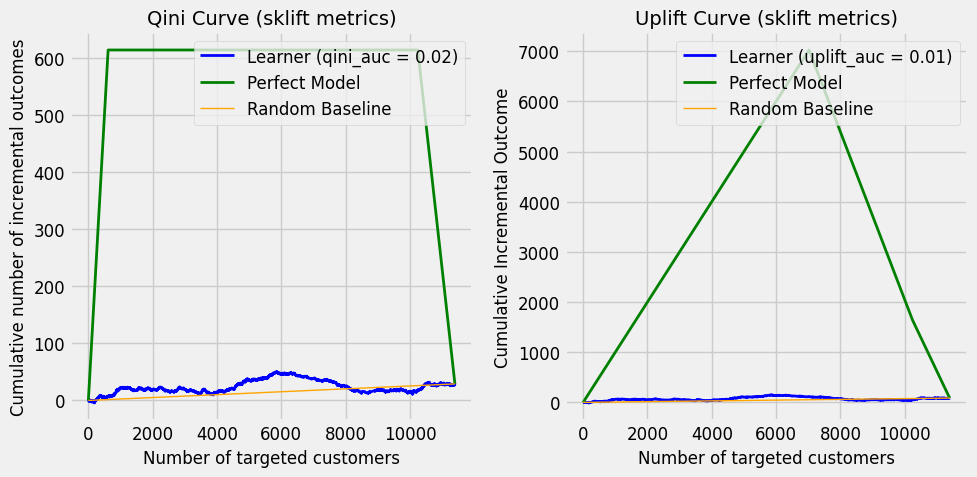

In [34]:
from causalml.inference.meta import BaseRLearner
import matplotlib.pyplot as plt
import utils
import xgboost as xgb
from xgboost import XGBClassifier, XGBRegressor

xg_params = est_params.copy()
xg_params.pop('verbose')
est_outcome = XGBClassifier(tree_method='hist', enable_categorical=True, **xg_params)
est_effect = XGBRegressor(tree_method='hist', enable_categorical=True, **xg_params)
est_prop = XGBClassifier(tree_method='hist', enable_categorical=True, **xg_params)

r_learner_model = BaseRLearner(
    outcome_learner=est_outcome,
    effect_learner=est_effect,
    propensity_learner=est_prop,
    control_name=0,
    random_state=est_params['random_state']
    )

r_learner_model.fit(X=X_train_cat, treatment=treat_train, y=y_train)

####
# predict
r_learner_pred = r_learner_model.predict(X_test_cat).squeeze()

# metrics
metrics_xgboost = utils.calc_uplift_metics(y_true=y_test, pred_uplift=r_learner_pred, treat_true=treat_test)
print(f'r_learner_model metrics_xgboost = {metrics_xgboost}')

# plot curve
fig, axs = plt.subplots(1, 2, figsize=(10, 5))
utils.plot_qini_curve(y_test, r_learner_pred, treat_test, axs=axs[0])
utils.plot_uplift_curve(y_test, r_learner_pred, treat_test, axs=axs[1])
plt.tight_layout()

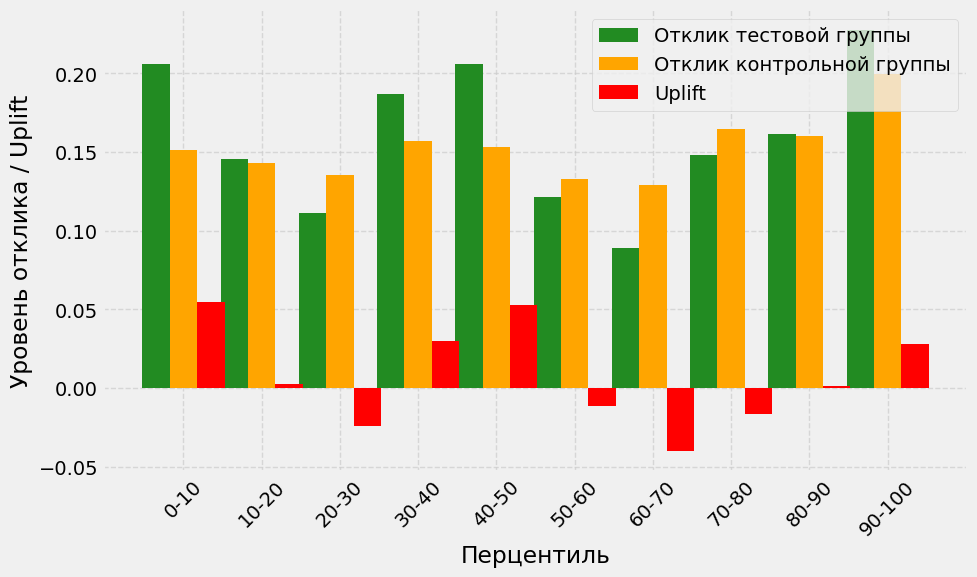

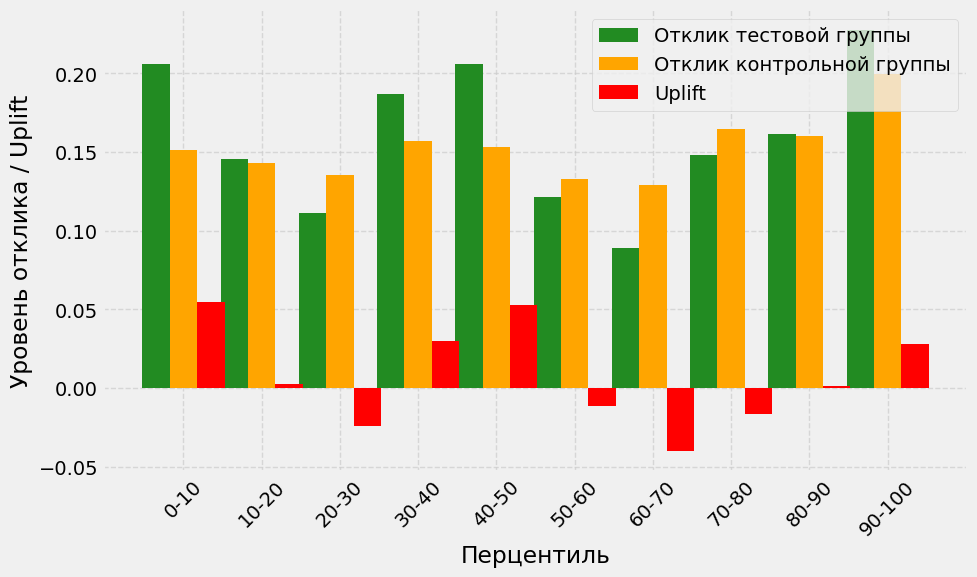

In [35]:
utils.custom_uplift_by_percentile(y_test, r_learner_pred, treat_test, kind='bar')

##### Сравнение метрик

In [22]:
%load_ext autoreload

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


,uplift_auc,qini_auc,uplift_at_30,uplift_auc_delta,qini_auc_delta,uplift_at_30_delta
baseline,0.0159,0.0324,0.0317,0.000000,0.000000,0.000000
uplift_tree_model,0.0204,0.0422,0.0336,0.283019,0.302469,0.059937
r_learner_model,0.0178,0.0369,0.0346,0.119497,0.138889,0.091483
r_learner_catboost,0.0243,0.0503,0.0443,0.528302,0.552469,0.397476
r_learner_xgboost,0.0079,0.0168,0.0111,-0.503145,-0.481481,-0.649842


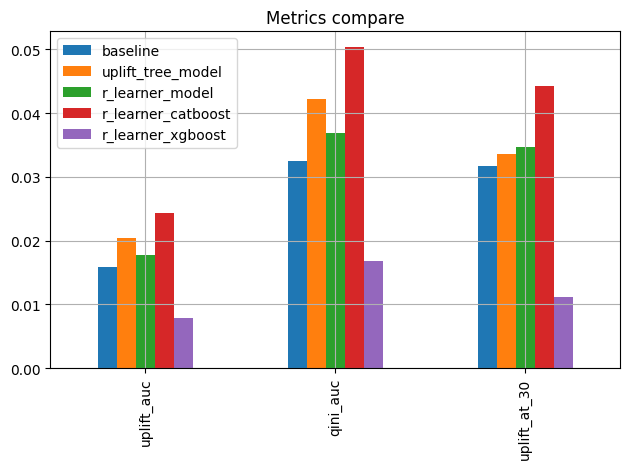

In [42]:
joint_metrics = pd.read_csv('models/joint_metrics.csv', index_col=0)
joint_metrics_adv_model = joint_metrics.copy()

joint_metrics_adv_model = utils.build_joint_metrics(joint_metrics_adv_model, 'r_learner_catboost', metrics_catboost)
joint_metrics_adv_model = utils.build_joint_metrics(joint_metrics_adv_model, 'r_learner_xgboost', metrics_xgboost)

display(joint_metrics_adv_model)

utils.plot_metrics_compare(joint_metrics_adv_model)

#Сохраним результат улучшения базовой модели
import os
path = 'model_improvement/1-adv-model'
os.makedirs(path, exist_ok=True)
joint_metrics_adv_model.to_csv(f'{path}/joint_metrics.csv')
plt.savefig(f'{path}/metrics_compare.png', bbox_inches='tight')


##### Вывод
- использование моделей catboost в качестве базовых для R-learner на тех же гиперпараметрах дало еще большее улучшение, чем в исходном виде
- модели xgboost на тех же гиперпараметрах показали ухудшение относительно baseline и всех остальных моделей
    - также замечено, что на самой последей версии xgboost xgboost-3.2.0 метрики лучше чем на текущей xgboost==2.0.3, но все равно сильно хуже всех остальных
- текущий лидер R-learner + catboost с Uplift@30% = 0.0443

____
Так как xgboost показал низкие результаты, вернем пока обратно версию sklearn
```bash
pip uninstall scikit-learn -y
pip install scikit-learn==1.6.1
```

#### Генерация признаков (опционально)

Рассмотрим добавление признаков с помощью autofeat
```bash
pip install autofeat==2.1.2
```

Сложные взаимодействия добавлять нецелесообразно, чтобы не переобучить модель редкими значениями и возможнями выбросами

In [31]:
from autofeat import AutoFeatClassifier

transformations = ('^2',) 
#transformations = ["1/", "exp", "log", "abs", "sqrt", "^2", "^3", "1+", "1-", "sin", "cos", "exp-", "2^"]

autofeat =  AutoFeatClassifier(
    categorical_cols=cat_features,
    feateng_cols=['recency', 'history'],
    transformations=transformations,
    feateng_steps=1,
    n_jobs=-1,
    verbose=True
)
X_train_features = autofeat.fit_transform(X_train_cat, y_train) 

print('new_feat_cols_')
display(autofeat.new_feat_cols_)

2026-07-18 13:04:29,933 INFO: [AutoFeat] The 1 step feature engineering process could generate up to 2 features.
2026-07-18 13:04:29,934 INFO: [AutoFeat] With 45588 data points this new feature matrix would use about 0.00 gb of space.
2026-07-18 13:04:29,944 INFO: [feateng] Step 1: transformation of original features


2026-07-18 13:04:30,256 INFO: [feateng] Generated 2 transformed features from 2 original features - done.
2026-07-18 13:04:30,260 INFO: [feateng] Generated altogether 2 new features in 1 steps
2026-07-18 13:04:30,261 INFO: [feateng] Removing correlated features, as well as additions at the highest level
2026-07-18 13:04:30,442 INFO: [feateng] Generated a total of 1 additional features


[featsel] Scaling data...done.
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 4 concurrent workers.


2026-07-18 13:04:30,469 INFO: [featsel] Feature selection run 1/5
2026-07-18 13:04:30,491 INFO: [featsel] Feature selection run 2/5
2026-07-18 13:04:30,501 INFO: [featsel] Feature selection run 3/5
2026-07-18 13:04:33,511 INFO: [featsel] Feature selection run 4/5


[Parallel(n_jobs=-1)]: Done   1 tasks      | elapsed:  1.8min


...

2026-07-18 13:08:34,682 INFO: [featsel] 17 features after 5 feature selection runs
/home/mle-user/mle_projects/sprint-5/mle-uplift-final-project-2025/.venv_mle-uplift-final-project-2025/lib/python3.10/site-packages/autofeat/featsel.py:270: FutureWarning: Series.ravel is deprecated. The underlying array is already 1D, so ravel is not necessary.  Use `to_numpy()` for conversion to a numpy array instead.
  if np.max(np.abs(correlations[c].ravel()[:i])) < 0.9:
2026-07-18 13:08:34,732 INFO: [featsel] 14 features after correlation filtering


[Parallel(n_jobs=-1)]: Done   5 out of   5 | elapsed:  4.1min finished


2026-07-18 13:08:46,866 INFO: [featsel] 0 features after noise filtering
2026-07-18 13:08:46,867 WARNING: [featsel] Not a single good features was found...
2026-07-18 13:08:46,868 INFO: [AutoFeat] Final dataframe with 21 feature columns (13 new).
2026-07-18 13:08:46,869 INFO: [AutoFeat] Training final classification model.
2026-07-18 13:10:03,300 INFO: [AutoFeat] Trained model: largest coefficients:
2026-07-18 13:10:03,302 INFO: [0.21870028]
2026-07-18 13:10:03,303 INFO: 0.459069 * cat_history_segment_6
2026-07-18 13:10:03,304 INFO: 0.388382 * cat_womens_1
2026-07-18 13:10:03,305 INFO: 0.321621 * cat_history_segment_1
2026-07-18 13:10:03,306 INFO: 0.315204 * cat_mens_1
2026-07-18 13:10:03,307 INFO: 0.314175 * cat_newbie_0
2026-07-18 13:10:03,307 INFO: 0.303793 * cat_womens_0
2026-07-18 13:10:03,308 INFO: 0.282660 * cat_zip_code_2
2026-07-18 13:10:03,309 INFO: 0.258874 * cat_history_segment_5
2026-07-18 13:10:03,309 INFO: 0.230615 * cat_mens_0
2026-07-18 13:10:03,310 INFO: 0.229587 * ca

new_feat_cols_


[]

Autofeat не выявил целеобразности добавления признаков, поэтому оставим все как есть

##### Применение новых признаков к лучшей модели

In [27]:
def add_features(df):
    df_add = df.copy()
    df_add['1/history'] = 1/df['history']
    df_add['history*recency**2'] = df['history'] * df['recency'].pow(2)
    df_add['1/(history*recency)'] = 1/(df['history'] * df['recency'])       
    return df_add

Но как то же случайно наверно получилось улучшение Uplift@30 до 0.05?
надо разобраться ..

In [77]:
est_params = {
    'n_estimators': 100,
    'max_depth': 6,
    'learning_rate':  0.03,
    'verbose': False,
    'random_state': RANDOM_STATE
}

r_learner_model metrics_catboost_feateng = {'uplift_auc': 0.0244, 'qini_auc': 0.0498, 'uplift_at_30': 0.05}


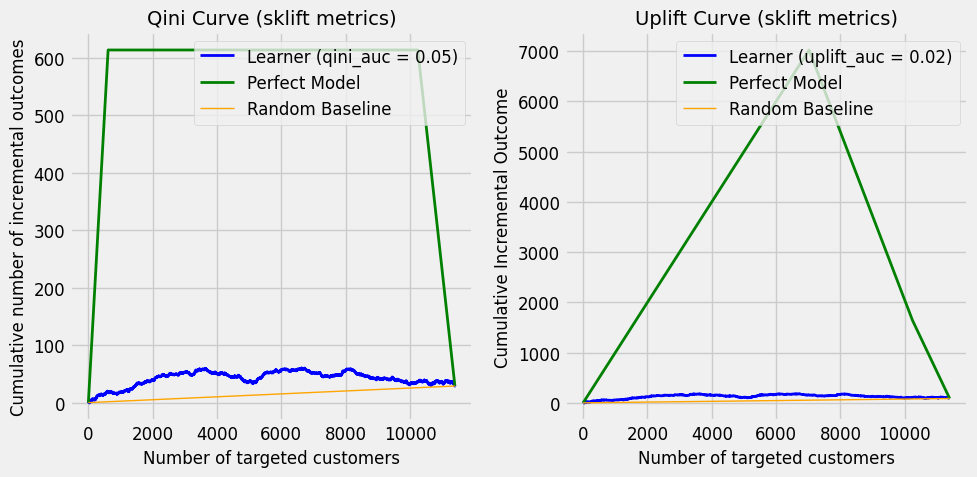

In [28]:
from causalml.inference.meta import BaseRLearner
import matplotlib.pyplot as plt
import utils
from catboost import CatBoostClassifier, CatBoostRegressor

est_outcome = CatBoostClassifier(cat_features=cat_features_indices, **est_params)   # **est_params
est_effect = CatBoostRegressor(cat_features=cat_features_indices, **est_params)     # **est_params
est_prop = CatBoostClassifier(cat_features=cat_features_indices, **est_params)      # **est_params

r_learner_model = BaseRLearner(
    n_fold=5,
    outcome_learner=est_outcome,
    effect_learner=est_effect,
    propensity_learner=est_prop,
    control_name=0,
    random_state=est_params['random_state']
    )

X_train_cat_add = add_features(X_train_cat)
X_test_cat_add = add_features(X_test_cat)

r_learner_model.fit(X=X_train_cat_add, treatment=treat_train, y=y_train)

# predict
r_learner_pred = r_learner_model.predict(X_test_cat_add).squeeze()

# metrics
metrics_catboost_feateng = utils.calc_uplift_metics(y_true=y_test, pred_uplift=r_learner_pred, treat_true=treat_test)
print(f'r_learner_model metrics_catboost_feateng = {metrics_catboost_feateng}')

# plot curve
fig, axs = plt.subplots(1, 2, figsize=(10, 5))
utils.plot_qini_curve(y_test, r_learner_pred, treat_test, axs=axs[0])
utils.plot_uplift_curve(y_test, r_learner_pred, treat_test, axs=axs[1])
plt.tight_layout()

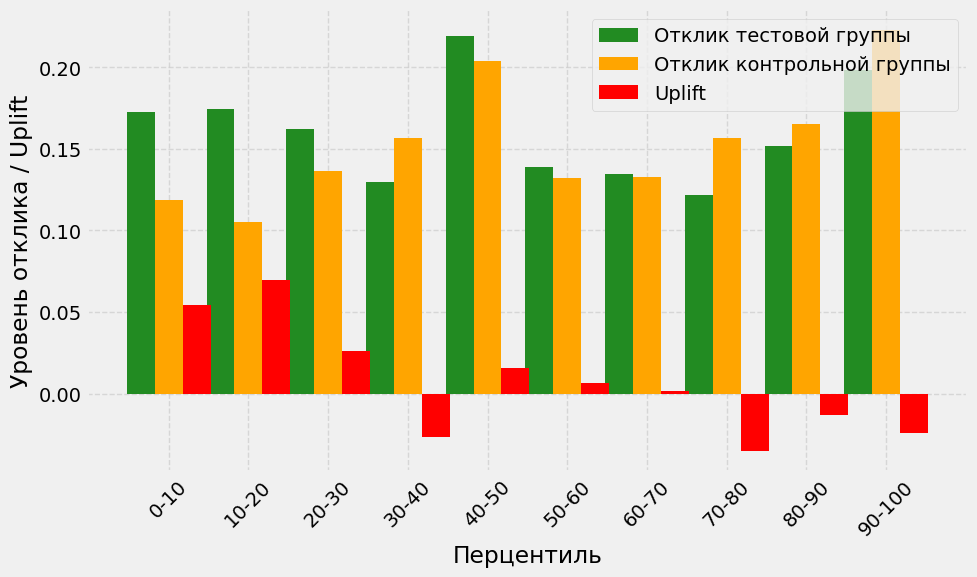

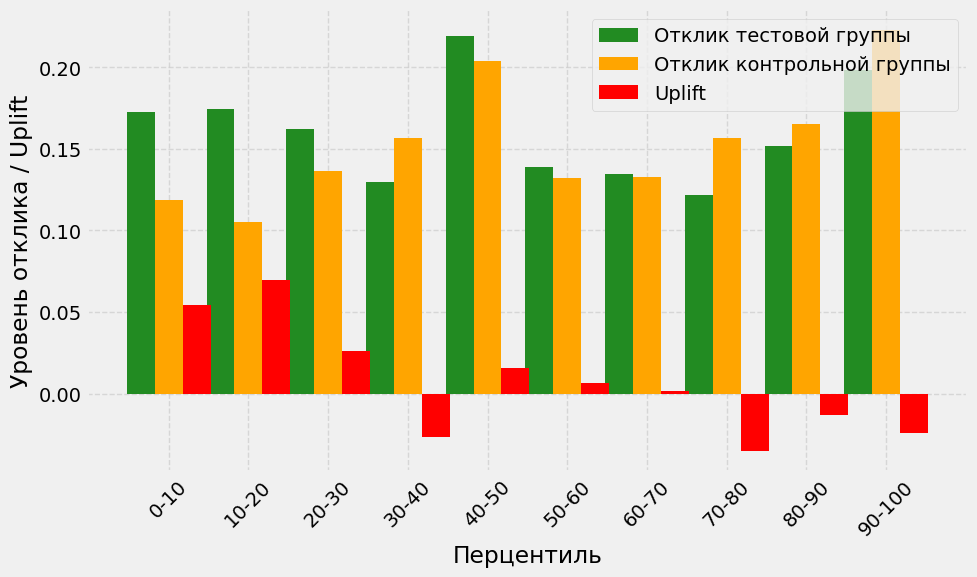

In [31]:
utils.custom_uplift_by_percentile(y_test, r_learner_pred, treat_test, kind='bar')

##### Сравнение метрик

,uplift_auc,qini_auc,uplift_at_30,uplift_auc_delta,qini_auc_delta,uplift_at_30_delta
baseline,0.0159,0.0324,0.0317,0.000000,0.000000,0.000000
uplift_tree_model,0.0204,0.0422,0.0336,0.283019,0.302469,0.059937
r_learner_model,0.0178,0.0369,0.0346,0.119497,0.138889,0.091483
r_learner_catboost,0.0243,0.0503,0.0443,0.528302,0.552469,0.397476
r_learner_xgboost,0.0079,0.0168,0.0111,-0.503145,-0.481481,-0.649842
r_learner_catboost_feateng,0.0244,0.0498,0.0500,0.534591,0.537037,0.577287


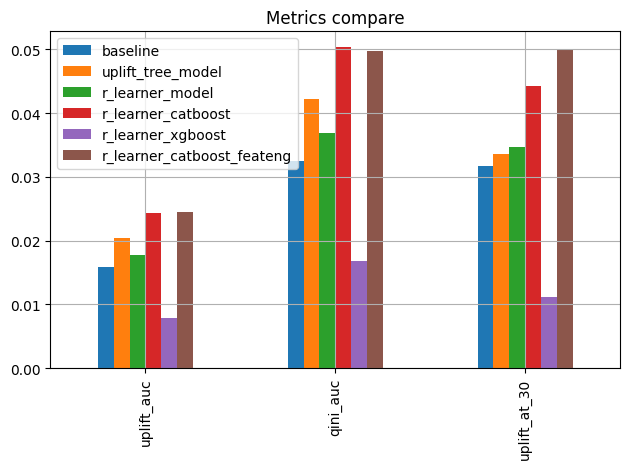

In [45]:
joint_metrics = pd.read_csv('model_improvement/1-adv-model/joint_metrics.csv', index_col=0)
joint_metrics_feateng = joint_metrics.copy()

joint_metrics_feateng = utils.build_joint_metrics(joint_metrics_feateng, 'r_learner_catboost_feateng', metrics_catboost_feateng)

display(joint_metrics_feateng)

utils.plot_metrics_compare(joint_metrics_feateng)

#Сохраним результат улучшения базовой модели
import os
path = 'model_improvement/2-feateng'
os.makedirs(path, exist_ok=True)
joint_metrics_feateng.to_csv(f'{path}/joint_metrics.csv')
plt.savefig(f'{path}/metrics_compare.png', bbox_inches='tight')


##### Вывод по генерации признаков

- удалось получить дополнительные признаки, на подвыборке данных (head(5000)), которые неожиданно улучшили метрику uplift_at_30 до 0.05
    - '1/history'
    - 'history*recency**2'
    - '1/(history*recency)'   
- качество лучшей модели еще подросло - uplift_at_30 = 0.05
    - 'uplift_auc': 0.0244, 
    - 'qini_auc': 0.0498, 
    - 'uplift_at_30': 0.05

- при этом при поиске признаков на всей выборке, улучшения параметров уже не происходило, и новые признаки вообще не появлялись,
- кроме того рекомедовано не добавлять сложные комбинации с делением на признаки, которые могут быть большие выбросы при малых значениях
- поэтому далее будем рассматривать варианты оптимизации гиперпараметров и с новыми признаками, и без них

- тем не менее поведение модели нестабильно и вызывает опасения, потому что на 40-м перцентиле модель серьезно промахивается

### Подбор гиперпараметров

In [ ]:
# какие были базовые параметры 
est_params = {
    'n_estimators': 100,
    'max_depth': 6,
    'learning_rate':  0.03,
    'verbose': False,
    'random_state': RANDOM_STATE
}

##### Optuna


###### Описание проводимых экспериментов
---

Развилка 1 
   - датасет с доп. фичами
   - или базовый

Развилка 2 
   - с универсальными параметрами всех 3-х моделей
   - или с различными параметрами для каждой модели - предпочтительно, так как модели решают разные задачи!

1. На 50-итерациях (для ускорения) с доп.фичами было получено значение ровно 0.05 - но не удалось сохранить 

2. Попробуем без доп.фич на универсальных параметрах моделей с более точными гиперпараметрами после первого круга поиска гиперпараметров с доп. фичами
   - не успех (не превысили 0.05 )
      - Best hyperparameters:  {'n_estimators': 160, 'max_depth': 6, 'learning_rate': 0.05}
      - Best score:  0.047915813945242386
   
3. Попробуем разделить гиперпараметры для двух моделей, так как они решают разные задача
3.1 - с доп. фичами
   - на 100 study trials
        - успех - было получено улучшение до 0.053
        - но, при незафиксированном random_state - случайность опять проявила лучшие параметры!
            - воспроизвести этот результат после фиксации random_state в TPESampler уже не удалось повторно
        - можно запомнить эти параметры и далее их использовать
            - Best is trial 44 with value: 0.053538328602554155 
            - parameters: 
            {
               'out_n_estimators': 100, 
               'out_max_depth': 7, 
               'out_learning_rate': 0.05, 
               'out_l2_reg': 6.0, 

               'eff_n_estimators': 100, 
               'eff_max_depth': 5, 
               'eff_learning_rate': 0.03, 
               'eff_l2_reg': 20.0, 
               'eff_random_strength': 0.5, 
            
               'prop_n_estimators': 150, 
               'prop_max_depth': 3, 
               'prop_learning_rate': 0.02, 
               'prop_l2_reg': 20.0}. 
            }
       - при фиксированном random_state в TPESampler на 100 итерациях
           - неуспешно (менее 0.05)
                - Best score:  0.04629347737508206
                - Best hyperparameters:  {'out_n_estimators': 100, 'out_max_depth': 8, 'out_learning_rate': 0.09, 'out_l2_reg': 10.0, 'eff_n_estimators': 50, 'eff_max_depth': 5, 'eff_learning_rate': 0.04, 'eff_l2_reg': 10.0, 'eff_random_strength': 1.5, 'prop_n_estimators': 150, 'prop_max_depth': 3, 'prop_learning_rate': 0.05, 'prop_l2_reg': 25.0}

3.2 - без доп. фич
    - не успех (менее 0.05)
    - Best score:  0.0457322433698881
    - Best hyperparameters:  {
           'out_n_estimators': 100, 
           'out_max_depth': 8, 
           'out_learning_rate': 0.04, 
           'out_l2_reg': 2.770994476999519, 
 
           'eff_n_estimators': 190, 
           'eff_max_depth': 4, 
           'eff_learning_rate': 0.05, 
           'eff_l2_reg': 10.672981921265748, 
           'eff_random_strength': 1.478769146036177, 
 
           'prop_n_estimators': 100, 
           'prop_max_depth': 4, 
           'prop_learning_rate': 0.05, 
           'prop_l2_reg': 27.96442543191775}


In [ ]:
import optuna
from optuna import create_study
from sklift.metrics import uplift_at_k
from causalml.inference.meta import BaseRLearner
from catboost import CatBoostClassifier, CatBoostRegressor
import logging

logging.getLogger("causalml").setLevel(logging.ERROR)

# с доп. фичами
X_train_cat_hp = add_features(X_train_cat)
X_test_cat_hp = add_features(X_test_cat)

# или с базовыми фичами
#X_train_cat_hp = X_train_cat 
#X_test_cat_hp = X_test_cat   

# case with common models params
def case_common_model_params(trial: optuna.Trial):
    param = {
        'n_estimators': trial.suggest_int('n_estimators', 100, 200, step=10),
        'max_depth': trial.suggest_int('max_depth', 6, 9, step=1),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.1, step=0.01),
        'verbose': False,
        'random_state': RANDOM_STATE
    }
    est_outcome = CatBoostClassifier(cat_features=cat_features_indices, **param)
    est_effect = CatBoostRegressor(cat_features=cat_features_indices, **param)
    est_prop = CatBoostClassifier(cat_features=cat_features_indices, **param)
    return est_outcome, est_effect, est_prop

def case_separate_model_params(trial: optuna.Trial):
    # --- 1. Параметры для Outcome Learner (модель базового отклика) ---
    outcome_params = {
        'n_estimators': trial.suggest_int('out_n_estimators', 100, 300, step=50),
        
        # можно дать чуть больше глубины и деревьев
        'max_depth': trial.suggest_int('out_max_depth', 5, 8),
        
        'learning_rate': trial.suggest_float('out_learning_rate', 0.03, 0.1, step=0.01),
        'l2_leaf_reg': trial.suggest_float('out_l2_leaf_reg', 1.0, 10.0, step=1),
        
        'verbose': 0,
        'random_state': RANDOM_STATE
    }
    
    # --- 2. Параметры для Effect Learner (модель аплифта) ---
    # критично - делаем ее более консервативной (глубина меньше, регуляризация выше!)
    effect_params = {
        'n_estimators': trial.suggest_int('eff_n_estimators', 50, 200, step=50),
        
        # Глубина 9 для аплифта — почти всегда переобучение
        'max_depth': trial.suggest_int('eff_max_depth', 3, 6), 
        
        'learning_rate': trial.suggest_float('eff_learning_rate', 0.01, 0.05, step=0.01),
        
        # Сильная регуляризация против шума
        'l2_leaf_reg': trial.suggest_float('eff_l2_leaf_reg', 5.0, 20.0, step=5), 
        
        # Добавляет случайность в сплиты
        'random_strength': trial.suggest_float('eff_random_strength', 0.0, 2.0, step=0.5), 
        
        'verbose': 0,
        'random_state': RANDOM_STATE
    }

    # --- 3. Параметры для Propensity Model (модель склонности к воздействию) ---
    propensity_params = {
        # Берем небольшое количество деревьев, чтобы модель не запоминала шум
        'n_estimators': trial.suggest_int('prop_n_estimators', 50, 150, step=50),
        
        # Очень важный параметр! Модель должна быть неглубокой (строить широкий выбор)
        'max_depth': trial.suggest_int('prop_max_depth', 3, 5), 
        
        'learning_rate': trial.suggest_float('prop_learning_rate', 0.01, 0.05, step=0.01),
        
        # Высокая регуляризация обязательна, чтобы избежать калибровки вероятностей около 0 и 1
        'l2_leaf_reg': trial.suggest_float('prop_l2_leaf_reg', 10.0, 30.0, step=5),
        
        'verbose': 0,
        'random_state': RANDOM_STATE
    }

    est_outcome = CatBoostClassifier(cat_features=cat_features_indices, **outcome_params)
    est_effect = CatBoostRegressor(cat_features=cat_features_indices, **effect_params)
    est_prop = CatBoostClassifier(cat_features=cat_features_indices, **propensity_params)
    
    return est_outcome, est_effect, est_prop

def objective(trial: optuna.Trial):

    #est_outcome, est_effect, est_prop = case_common_model_params(trial)
    est_outcome, est_effect, est_prop = case_separate_model_params(trial)

    r_learner_model = BaseRLearner(
        n_fold=3,
        outcome_learner=est_outcome,
        effect_learner=est_effect,
        propensity_learner=est_prop,
        control_name=0,
        random_state=est_params['random_state']
    )
    r_learner_model.fit(X=X_train_cat_hp, treatment=treat_train, y=y_train)

    # predict
    pred = r_learner_model.predict(X_test_cat_hp).squeeze()

    # metrics
    uplift_at_30 = uplift_at_k(y_test, pred, treat_test, k=0.3, strategy='overall')
    return uplift_at_30

# Создаем и запускаем исследование
path = 'model_improvement/3-hyperparam/optuna'
OPTUNA_DB_FILE = f'{path}/optuna.study.db'
STUDY_DB_NAME = f"sqlite:///{OPTUNA_DB_FILE}"
STUDY_NAME = "rlearner-catboost-hyperparams"

if optuna.get_all_study_names(STUDY_DB_NAME).__contains__(STUDY_NAME):
    optuna.delete_study(study_name=STUDY_NAME, storage=STUDY_DB_NAME)
    #pass

sampler = optuna.samplers.TPESampler(seed=RANDOM_STATE)

study = create_study(study_name=STUDY_NAME, storage=STUDY_DB_NAME, load_if_exists=True, direction='maximize')
study.optimize(objective, n_trials=100) #n_trials=100

# Выводим лучшие гиперпараметры
print("Best hyperparameters: ", study.best_params)
print("Best score: ", study.best_value)


Предварительный итог (не был зафиксирован TPESampler random_state) - запомним эти параметры, так как первысили 0.05

[I 2026-07-18 21:49:05,326] Trial 44 finished with value: 0.053538328602554155 and parameters: {
    'out_n_estimators': 100, 
    'out_max_depth': 7, 
    'out_learning_rate': 0.05, 
    'out_l2_reg': 6.0, 

    'eff_n_estimators': 100, 
    'eff_max_depth': 5, 
    'eff_learning_rate': 0.03, 
    'eff_l2_reg': 20.0, 
    'eff_random_strength': 0.5, 
    
    'prop_n_estimators': 150, 
    'prop_max_depth': 3, 
    'prop_learning_rate': 0.02, 
    'prop_l2_reg': 20.0}. 
Best is trial 44 with value: 0.053538328602554155.


Завершен расчет на 100 попыток - колебание (ухудщение) из-за незафиксированного random_state в TPESampler
Повторить гарантированно еще раз такую высокую метрику не удалось при фиксированном random_state

[I 2026-07-19 07:09:07,511] Trial 78 finished with value: 0.04713959037886585 and parameters: {
    'out_n_estimators': 100, 
    'out_max_depth': 5, 
    'out_learning_rate': 0.05, 
    'out_l2_reg': 9.0, 

    'eff_n_estimators': 200, 
    'eff_max_depth': 6, 
    'eff_learning_rate': 0.03, 
    'eff_l2_reg': 10.0, 
    'eff_random_strength': 1.5, 
    
    'prop_n_estimators': 100, 
    'prop_max_depth': 3, 
    'prop_learning_rate': 0.04, 
    'prop_l2_reg': 15.0}. 
Best is trial 78 with value: 0.04713959037886585.


Подготовим функцию для быстрого применения параметров от различных экспериментов

In [15]:
def parse_params(param_from_trial: dict, optuna=True):
    prefix_outcome = 'out_' if optuna else 'outcome_model__'
    prefix_effect = 'eff_' if optuna else 'effect_model__'
    prefix_propensity = 'prop_' if optuna else 'propensity_model__'

    outcome_params = {
        'n_estimators': param_from_trial[prefix_outcome + 'n_estimators'],
        'max_depth': param_from_trial[prefix_outcome + 'max_depth'],
        'learning_rate': param_from_trial[prefix_outcome + 'learning_rate'],
        'l2_leaf_reg': param_from_trial[prefix_outcome + 'l2_leaf_reg'],    
        'verbose': 0,
        'random_state': RANDOM_STATE
    }
    effect_params = {
        'n_estimators': param_from_trial[prefix_effect + 'n_estimators'],
        'max_depth': param_from_trial[prefix_effect + 'max_depth'],
        'learning_rate': param_from_trial[prefix_effect + 'learning_rate'],
        'l2_leaf_reg': param_from_trial[prefix_effect + 'l2_leaf_reg'],    
        'random_strength': param_from_trial[prefix_effect + 'random_strength'],
        'verbose': 0,
        'random_state': RANDOM_STATE
    }

    propensity_params = {
        'n_estimators': param_from_trial[prefix_propensity + 'n_estimators'],
        'max_depth': param_from_trial[prefix_propensity + 'max_depth'],
        'learning_rate': param_from_trial[prefix_propensity + 'learning_rate'],
        'l2_leaf_reg': param_from_trial[prefix_propensity + 'l2_leaf_reg'],    
        'verbose': 0,
        'random_state': RANDOM_STATE
    }

    return outcome_params, effect_params, propensity_params

Воспроизведем расчет с наилучшей полученной метрикой и ее параметрами

In [ ]:
#[I 2026-07-18 21:49:05,326] Trial 44 finished with value: 0.053538328602554155 and parameters: {

outcome_params, effect_params, propensity_params = parse_params(
    {
    'out_n_estimators': 100, 
    'out_max_depth': 7, 
    'out_learning_rate': 0.05, 
    'out_l2_leaf_reg': 6.0, 

    'eff_n_estimators': 100, 
    'eff_max_depth': 5, 
    'eff_learning_rate': 0.03, 
    'eff_l2_leaf_reg': 20.0, 
    'eff_random_strength': 0.5, 
    
    'prop_n_estimators': 150, 
    'prop_max_depth': 3, 
    'prop_learning_rate': 0.02, 
    'prop_l2_leaf_reg': 20.0
    }
)

est_outcome = CatBoostClassifier(cat_features=cat_features_indices, **outcome_params)
est_effect = CatBoostRegressor(cat_features=cat_features_indices, **effect_params)
est_prop = CatBoostClassifier(cat_features=cat_features_indices, **propensity_params)

In [49]:
X_train_cat_hp = add_features(X_train_cat)
X_test_cat_hp = add_features(X_test_cat)

#X_train_cat_hp = X_train_cat
#X_test_cat_hp = X_test_cat

r_learner_model metrics_catboost_feateng_hyper = {'uplift_auc': 0.0235, 'qini_auc': 0.0482, 'uplift_at_30': 0.0535}


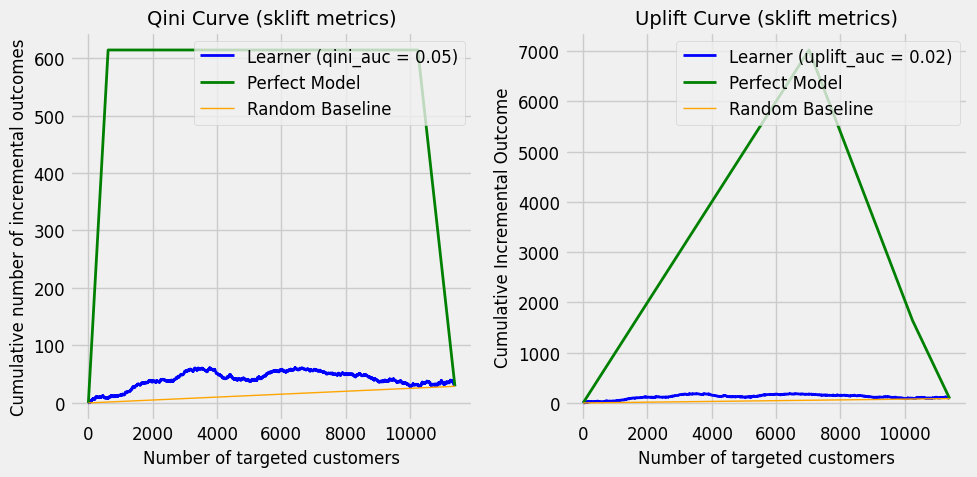

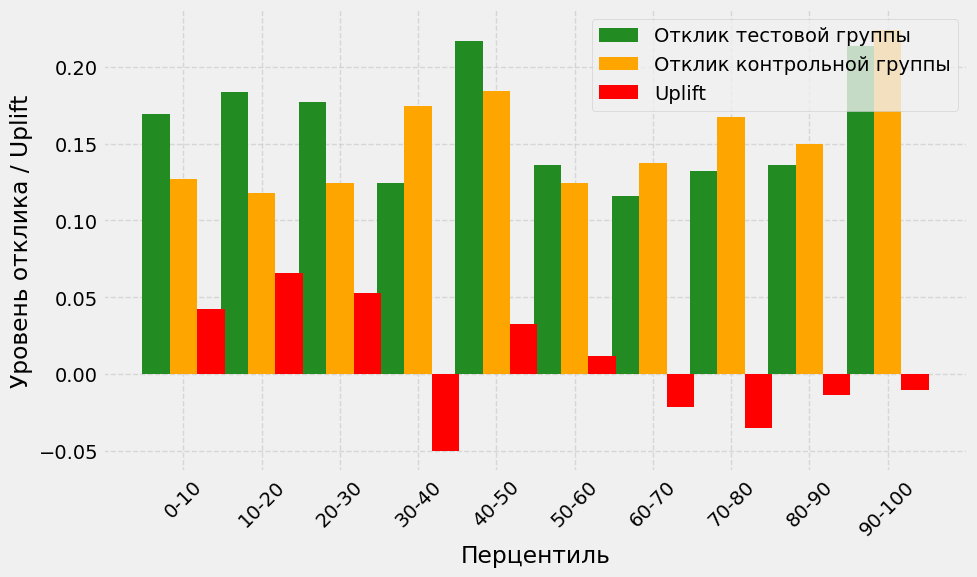

In [50]:
r_learner_model = BaseRLearner(
    n_fold=5,
    outcome_learner=est_outcome,
    effect_learner=est_effect,
    propensity_learner=est_prop,
    control_name=0,
    random_state=est_params['random_state']
)
r_learner_model.fit(X=X_train_cat_hp, treatment=treat_train, y=y_train)

# predict
pred = r_learner_model.predict(X_test_cat_hp).squeeze()

# metrics
metrics = utils.calc_uplift_metics(y_test, pred, treat_test)
print(f'r_learner_model metrics_catboost_feateng_hyper = {metrics}')

# plot curve
import matplotlib.pyplot as plt
import utils
fig, axs = plt.subplots(1, 2, figsize=(10, 5))
utils.plot_qini_curve(y_test, pred, treat_test, axs=axs[0])
utils.plot_uplift_curve(y_test, pred, treat_test, axs=axs[1])
plt.tight_layout()

fig = utils.custom_uplift_by_percentile(y_test, pred, treat_test, kind='bar')
fig.show()

##### RandomSearchCV
Рассмотрим вариант с RandomSearchCV

In [ ]:
# Упаковываем y и treatment внутрь X, чтобы RandomizedSearchCV автоматически 
# нарезал их на фолды вместе с признаками.

# вариант 1 - с доп. признаками 
#X_train_full_tmp = add_features(X_train_cat).copy()
# результаты сохранены - TODO - итоговые метрики не сохранены - добавить

# вариант 2 - без признаками 
X_train_full_tmp = X_train_cat.copy()
# результаты сохранены 

X_train_full_tmp['__target__'] = y_train
X_train_full_tmp['__treatment__'] = treat_train

In [10]:
import pandas as pd
import numpy as np
from catboost import CatBoostClassifier, CatBoostRegressor
from causalml.inference.meta import BaseRLearner 
from sklearn.base import BaseEstimator
from sklearn.model_selection import StratifiedKFold, RandomizedSearchCV
from sklift.metrics import uplift_at_k

# 1. Создаем единый вектор стратификации (4 группы: 0, 1, 2, 3)
# Он гарантирует, что в каждом фолде будет поровну объектов из всех 4 состояний
strata_groups = (2 * y_train + treat_train).astype(int)

# 2. Инициализируем стандартный StratifiedKFold
cv_splitter = StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)

# 1. Создаем класс-обертку, чтобы объединить 3 модели в один Estimator для sklearn
class CausalRlearnerWrapper(BaseEstimator):
    def __init__(
        self, 
        # Передаем сами объекты моделей в init. 
        # Scikit-learn теперь увидит их и сможет прокидывать параметры через "__"
        outcome_model=None,
        effect_model=None,
        propensity_model=None,
        cat_features=cat_features_indices, 
        random_state=est_params['random_state']
    ):
        self.outcome_model = outcome_model
        self.effect_model = effect_model
        self.propensity_model = propensity_model

        self.cat_features = cat_features
        self.random_state = random_state

        # параметры по-умолчанию
        self.outcome_model.set_params(
            n_estimators=100, 
            max_depth=5, 
            learning_rate=0.03, 
            l2_leaf_reg=1.0,

            cat_features=self.cat_features, 
            random_state=self.random_state, 
            verbose=0
        )
        self.effect_model.set_params(
            n_estimators=50, 
            max_depth=3, 
            learning_rate=0.01, 
            l2_leaf_reg=5.0, 
            random_strength=0.0,

            cat_features=self.cat_features, 
            random_state=self.random_state, 
            verbose=0
        )
        self.propensity_model.set_params(
            n_estimators=50, 
            max_depth=3, 
            learning_rate=0.01, 
            l2_leaf_reg=10.0,

            cat_features=self.cat_features, 
            random_state=self.random_state, 
            verbose=0
        )

    def fit(self, X, y=None):
        # Извлекаем реальный y и treatment из переданного X
        y_real = X['__target__'].values
        treatment_real = X['__treatment__'].values
        
        # Оставляем только признаки для обучения CatBoost моделей
        X_features = X.drop(columns=['__target__', '__treatment__'])
       
        # Собираем BaseRLearner из causalml
        self.uplift_model = BaseRLearner(
            n_fold=2, # we already use folds at RandomSearchCV
            outcome_learner=self.outcome_model,
            effect_learner=self.effect_model,
            propensity_learner=self.propensity_model,
            control_name=0,
            random_state=est_params['random_state']
        )
        
        # Обучаем модель. Примечание: X должен содержать признаки, 
        # y - целевую переменную, treatment - бинарный вектор воздействия.
        self.uplift_model.fit(X=X_features, treatment=treatment_real, y=y_real)
        return self

    def predict(self, X):
        # Если в predict прилетит датафрейм со служебными колонками, чистим его
        if '__target__' in X.columns:
            X = X.drop(columns=['__target__', '__treatment__'])
        
        # Метод для оценки аплифта на тестовых данных
        return self.uplift_model.predict(X)


# 2. Определение сетки параметров (Замена trial.suggest из Optuna)
# Используем списки для дискретных шагов (совпадает со step в Optuna)
param_distributions = {
    # --- Outcome Learner ---
    'outcome_model__n_estimators': np.arange(100, 300+1, step=50).tolist(),
    'outcome_model__max_depth': np.arange(5, 8+1).tolist(),
    'outcome_model__learning_rate': np.arange(0.03, 0.10+0.01, 0.01).tolist(),
    'outcome_model__l2_leaf_reg': np.arange(1.0, 10.0+1, 1.0).tolist(),
    
    # --- Effect Learner ---
    'effect_model__n_estimators': np.arange(50, 200+1, step=50),
    'effect_model__max_depth': np.arange(3, 6+1).tolist(),
    'effect_model__learning_rate': np.arange(0.01, 0.05+0.01, 0.01).tolist(),
    'effect_model__l2_leaf_reg': np.arange(5.0, 20.0+1, 5.0).tolist(),
    'effect_model__random_strength': np.arange(0.0, 2.0+0.1, 0.5).tolist(),
    
    # --- Propensity Model ---
    'propensity_model__n_estimators': np.arange(50, 150+1, step=50),
    'propensity_model__max_depth': np.arange(3, 5+1).tolist(),
    'propensity_model__learning_rate': np.arange(0.01, 0.05+0.01, 0.01).tolist(),
    'propensity_model__l2_leaf_reg': np.arange(10.0, 30.0+0.01, 5.0).tolist(),
}

# 1. Создаем кастомный скорер для аплифта 
def uplift_stratified_scorer(estimator, X, y_ignored):
    # Извлекаем таргет и тритмент, которые sklearn нарезал для валидационного фолда
    y_true = X['__target__'].values
    treatment = X['__treatment__'].values

    # Дропаем служебные колонки, чтобы получить чистые признаки для предсказания
    X_features = X.drop(columns=['__target__', '__treatment__'])

    # Предсказываем эффект (CATE)
    pred = estimator.predict(X_features).flatten()
    
    uplift_at_30 = uplift_at_k(y_true, pred, treatment, k=0.3, strategy='overall')
    print(f'uplift_at_30 = {uplift_at_30}')

    return uplift_at_30

# 2. Инициализируем нашу обертку

# Создаем "пустые" базовые модели, которые передадим в обертку
init_outcome = CatBoostClassifier()
init_effect = CatBoostRegressor()
init_propensity = CatBoostClassifier()

base_wrapper = CausalRlearnerWrapper(
    cat_features=cat_features_indices, 
    random_state=RANDOM_STATE,
    outcome_model=init_outcome,
    effect_model=init_effect,
    propensity_model=init_propensity
)

# 3. Настраиваем рандомизированный поиск
random_search = RandomizedSearchCV(
    estimator=base_wrapper,
    param_distributions=param_distributions,
    n_iter=100, # Количество случайных комбинаций
    scoring=uplift_stratified_scorer, # Использует распаковку внутри фолда
    cv=cv_splitter, # Наш StratifiedKFold
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbose=2
)

# 4. Запуск поиска 
# ЗАПУСК: Передаем strata_groups в качестве y. 
# Сплиттер посмотрит на него и идеально сбалансирует фолды по (target + treatment).
random_search.fit(X=X_train_full_tmp, y=strata_groups)


Fitting 3 folds for each of 100 candidates, totalling 300 fits


uplift_at_30 = 0.04617700648090414
[CV] END effect_model__l2_leaf_reg=20.0, effect_model__learning_rate=0.02, effect_model__max_depth=4, effect_model__n_estimators=50, effect_model__random_strength=0.5, outcome_model__l2_leaf_reg=3.0, outcome_model__learning_rate=0.04, outcome_model__max_depth=5, outcome_model__n_estimators=250, propensity_model__l2_leaf_reg=15.0, propensity_model__learning_rate=0.04, propensity_model__max_depth=3, propensity_model__n_estimators=50; total time=  22.4s
uplift_at_30 = 0.047243153427075024
[CV] END effect_model__l2_leaf_reg=20.0, effect_model__learning_rate=0.03, effect_model__max_depth=3, effect_model__n_estimators=150, effect_model__random_strength=1.0, outcome_model__l2_leaf_reg=7.0, outcome_model__learning_rate=0.07, outcome_model__max_depth=6, outcome_model__n_estimators=200, propensity_model__l2_leaf_reg=10.0, propensity_model__learning_rate=0.02, propensity_model__max_depth=4, propensity_model__n_estimators=100; total time=  23.9s
uplift_at_30 = 0.

/home/mle-user/mle_projects/sprint-5/mle-uplift-final-project-2025/.venv_mle-uplift-final-project-2025/lib/python3.10/site-packages/numpy/ma/core.py:2820: RuntimeWarning: invalid value encountered in cast
  _data = np.array(data, dtype=dtype, copy=copy,


RandomizedSearchCV(cv=StratifiedKFold(n_splits=3, random_state=43, shuffle=True),
                   estimator=CausalRlearnerWrapper(effect_model=<catboost.core.CatBoostRegressor object at 0x7f293f597d30>,
                                                   outcome_model=<catboost.core.CatBoostClassifier object at 0x7f293f597d60>,
                                                   propensity_model=<catboost.core.CatBoostClassifier object at 0x7f293f5952a0>),
                   n_iter=100, n_jobs=-1,
                   par...
                                                                     8],
                                        'outcome_model__n_estimators': [100,
                                                                        150,
                                                                        200,
                                                                        250,
                                                                        300],
                                        'propensity_model__l2_leaf_reg': [10.0,
                                                                          15.0,
                                                                          20.0,
                                                                          25.0,
                                                                          30.0],
                                        'propensity_model__learning_rate': [0.01,
                                                                            0.02,
                                                                            0.03,
                                                                            0.04,
                                                                            0.05],
                                        'propensity_model__max_depth': [3, 4,
                                                                        5],
                                        'propensity_model__n_estimators': array([ 50, 100, 150])},
                   random_state=43,
                   scoring=<function uplift_stratified_scorer at 0x7f2960821f30>,
                   verbose=2)

In [11]:
rs_best_params = random_search.best_params_
print(f'random_search best params:')
display(rs_best_params)

print(f'random_search best score: {random_search.best_score_} at trial: {random_search.best_index_}')

rs_results = pd.DataFrame(random_search.cv_results_)
print(f'made iterations count: {rs_results.shape}')

random_search best params:


{'propensity_model__n_estimators': 150,
 'propensity_model__max_depth': 5,
 'propensity_model__learning_rate': 0.02,
 'propensity_model__l2_leaf_reg': 25.0,
 'outcome_model__n_estimators': 300,
 'outcome_model__max_depth': 7,
 'outcome_model__learning_rate': 0.03,
 'outcome_model__l2_leaf_reg': 4.0,
 'effect_model__random_strength': 2.0,
 'effect_model__n_estimators': 50,
 'effect_model__max_depth': 4,
 'effect_model__learning_rate': 0.04,
 'effect_model__l2_leaf_reg': 20.0}

random_search best score: 0.05129764033230292 at trial: 52
made iterations count: (100, 24)


###### Сохраним результат работы RandomSearchCV для кейса с фичами на 100 итерациях

In [12]:
import json
import os

feature_types = ['new_features', 'base_features'] 

#feature_type = feature_types[0]
feature_type = feature_types[1]

path = 'model_improvement/3-hyperparam/random-search' + '/' + feature_type
os.makedirs(path, exist_ok=True)

# results
rs_results.to_csv(f'{path}/rs_results.csv')

# params
# convert types to native to save json
params_df = pd.DataFrame([rs_best_params])
with open(f'{path}/rs_best_params.json', 'w', encoding='UTF-8') as f:
    json.dump(params_df.loc[0].to_dict(), f, indent=4)

# score
with open(f'{path}/rs_score.json', 'w', encoding='UTF-8') as f:
    json.dump({
        'best_score': float(random_search.best_score_),
        'best_index': int(random_search.best_index_)
        },
        f, indent=4)

###### Выполним расчет на оптимальных параметрах

r_learner_model random_search hyper params metrics = {'uplift_auc': 0.0198, 'qini_auc': 0.0411, 'uplift_at_30': 0.0274}


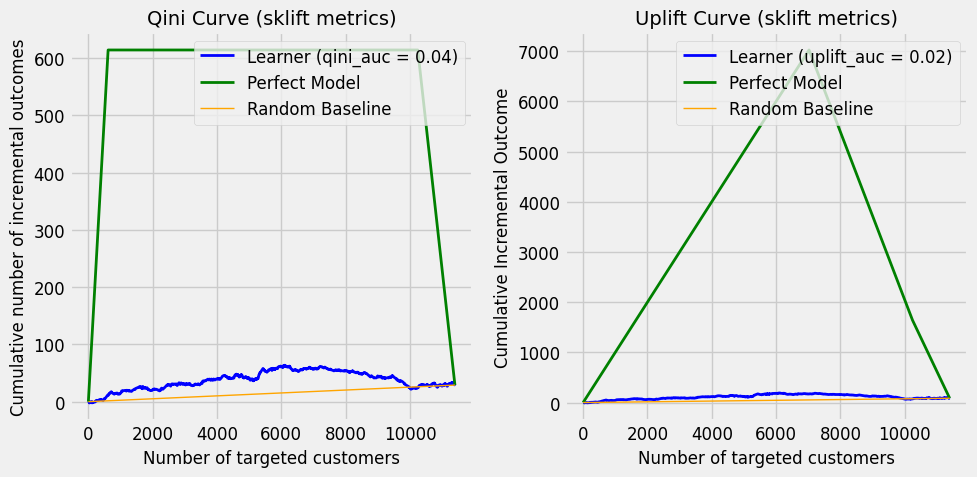

In [25]:
import matplotlib.pyplot as plt
import utils

# final params from random search - 100 iters - base features

outcome_params, effect_params, propensity_params = parse_params(
{
    'propensity_model__n_estimators': 150,
    'propensity_model__max_depth': 5,
    'propensity_model__learning_rate': 0.02,
    'propensity_model__l2_leaf_reg': 25.0,
    'outcome_model__n_estimators': 300,
    'outcome_model__max_depth': 7,
    'outcome_model__learning_rate': 0.03,
    'outcome_model__l2_leaf_reg': 4.0,
    'effect_model__random_strength': 2.0,
    'effect_model__n_estimators': 50,
    'effect_model__max_depth': 4,
    'effect_model__learning_rate': 0.04,
    'effect_model__l2_leaf_reg': 20.0
}, optuna=False
)

est_outcome = CatBoostClassifier(cat_features=cat_features_indices, **outcome_params)
est_effect = CatBoostRegressor(cat_features=cat_features_indices, **effect_params)
est_prop = CatBoostClassifier(cat_features=cat_features_indices, **propensity_params)

r_learner_model = BaseRLearner(
    n_fold=5,
    outcome_learner=est_outcome,
    effect_learner=est_effect,
    propensity_learner=est_prop,
    control_name=0,
    random_state=est_params['random_state']
)
r_learner_model.fit(X=X_train_cat, treatment=treat_train, y=y_train)

# predict
uplift_pred = r_learner_model.predict(X_test_cat).squeeze()

# metrics
metrics = utils.calc_uplift_metics(y_true=y_test, pred_uplift=uplift_pred, treat_true=treat_test)
print(f'r_learner_model random_search hyper params metrics = {metrics}')

# score
with open(f'{path}/metrics.json', 'w', encoding='UTF-8') as f:
    json.dump(metrics, f, indent=4)

# plot curve
fig, axs = plt.subplots(1, 2, figsize=(10, 5))
utils.plot_qini_curve(y_test, uplift_pred, treat_test, axs=axs[0])
utils.plot_uplift_curve(y_test, uplift_pred, treat_test, axs=axs[1])
plt.tight_layout()

###### Вывод
- метрика на тестовой выборке показала ухудшение, видимо модель все-таки переобучилась
    - это поведение как на базовых признаках
        - 'uplift_auc': 0.0198, 
        - 'qini_auc': 0.0411, 
        - 'uplift_at_30': 0.0274
        
    - так и на дополнительных
        - ... 
- итого перебор гиперпараметров RandomSearchCV не привел к появлению лучшей модели после валидации на тестовой выборке

##### Сохраним логи и результаты optuna

In [ ]:
# make folder

import os

path = 'model_improvement/3-hyperparam'
os.makedirs(path, exist_ok=True)

In [ ]:
# best params
import json

display(study.best_params)

with open(f'{path}/best_params.json', 'w', encoding='UTF-8') as f:
    json.dump(study.best_params, f, indent=4)

{'n_estimators': 150, 'max_depth': 8, 'learning_rate': 0.05263174463929155}

In [ ]:
# study iterations

optuna_log_df = study.trials_dataframe()
display(optuna_log_df)

optuna_log_df.to_csv(f'{path}/optuna_log_df.csv', index=False)

,number,value,datetime_start,datetime_complete,duration,params_learning_rate,params_max_depth,params_n_estimators,state
0,0,0.027627,2026-07-17 19:56:20.791852,2026-07-17 19:57:10.251192,0 days 00:00:49.459340,0.002390,8,300,COMPLETE
1,1,0.030878,2026-07-17 19:57:10.252090,2026-07-17 19:57:18.050288,0 days 00:00:07.798198,0.083119,4,150,COMPLETE
2,2,0.029406,2026-07-17 19:57:18.051447,2026-07-17 19:57:58.743381,0 days 00:00:40.691934,0.006255,4,300,COMPLETE
3,3,0.032079,2026-07-17 19:57:58.744419,2026-07-17 19:58:14.451025,0 days 00:00:15.706606,0.007198,9,150,COMPLETE
4,4,0.027912,2026-07-17 19:58:14.452316,2026-07-17 19:58:55.612962,0 days 00:00:41.160646,0.001082,8,250,COMPLETE
...,...,...,...,...,...,...,...,...,...
95,95,0.039544,2026-07-17 20:27:29.896552,2026-07-17 20:27:45.163512,0 days 00:00:15.266960,0.023332,10,150,COMPLETE
96,96,0.038049,2026-07-17 20:27:45.164429,2026-07-17 20:27:56.486398,0 days 00:00:11.321969,0.073756,5,150,COMPLETE
97,97,0.044479,2026-07-17 20:27:56.487389,2026-07-17 20:28:02.486152,0 days 00:00:05.998763,0.036886,9,50,COMPLETE
98,98,0.042725,2026-07-17 20:28:02.487330,2026-07-17 20:28:18.109786,0 days 00:00:15.622456,0.014812,9,150,COMPLETE


/tmp/ipykernel_16235/562447192.py:3: ExperimentalWarning: plot_optimization_history is experimental (supported from v2.2.0). The interface can change in the future.
  vis.plot_optimization_history(study)


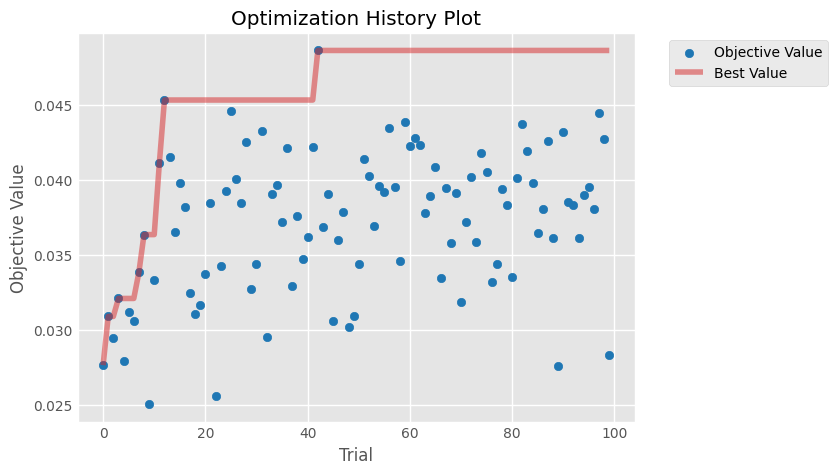

In [58]:
import optuna.visualization.matplotlib as vis

vis.plot_optimization_history(study)
plt.savefig(f'{path}/plot_optimization_history.png')

/tmp/ipykernel_16235/1674264181.py:1: ExperimentalWarning: plot_contour is experimental (supported from v2.2.0). The interface can change in the future.
  vis.plot_contour(study)


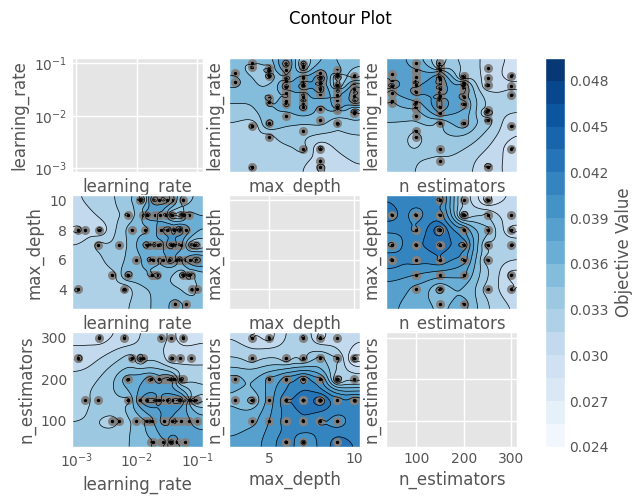

In [59]:
vis.plot_contour(study)
plt.savefig(f'{path}/plot_contour.png')

/tmp/ipykernel_16235/1324287341.py:1: ExperimentalWarning: plot_edf is experimental (supported from v2.2.0). The interface can change in the future.
  vis.plot_edf(study)


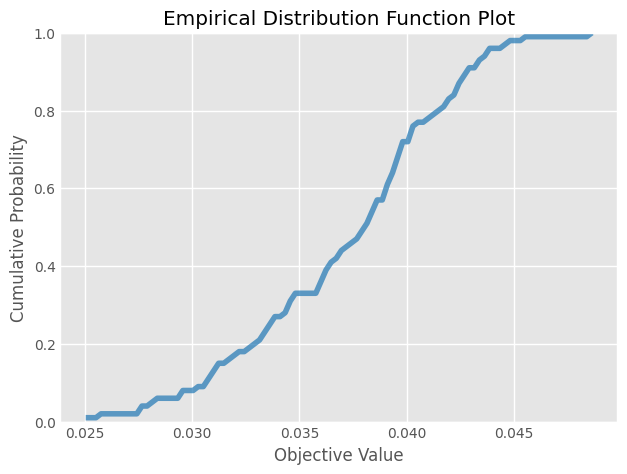

In [60]:
vis.plot_edf(study)
plt.savefig(f'{path}/plot_edf.png')

/tmp/ipykernel_16235/4262228324.py:1: ExperimentalWarning: plot_slice is experimental (supported from v2.2.0). The interface can change in the future.
  vis.plot_slice(study)


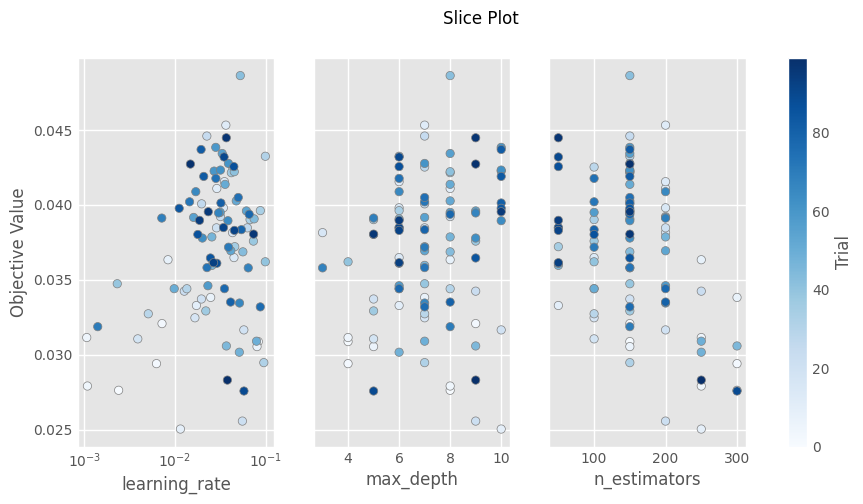

In [65]:
vis.plot_slice(study)
plt.savefig(f'{path}/plot_slice.png')

/tmp/ipykernel_16235/3964268479.py:1: ExperimentalWarning: plot_param_importances is experimental (supported from v2.2.0). The interface can change in the future.
  vis.plot_param_importances(study)


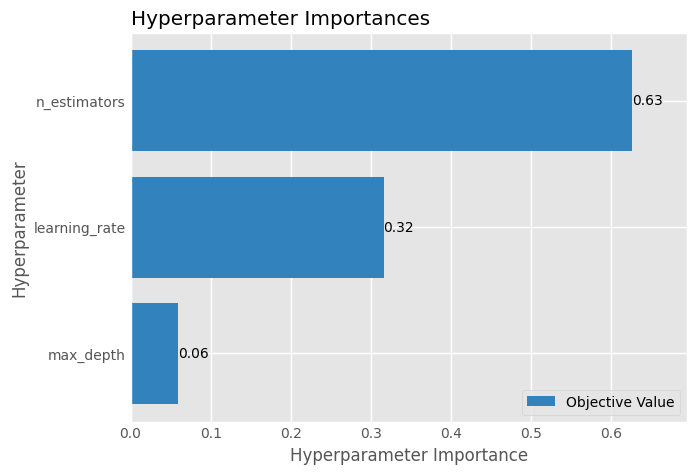

In [67]:
vis.plot_param_importances(study)
plt.savefig(f'{path}/plot_param_importances.png')

/tmp/ipykernel_16235/3557655916.py:1: ExperimentalWarning: plot_rank is experimental (supported from v3.2.0). The interface can change in the future.
  vis.plot_rank(study)


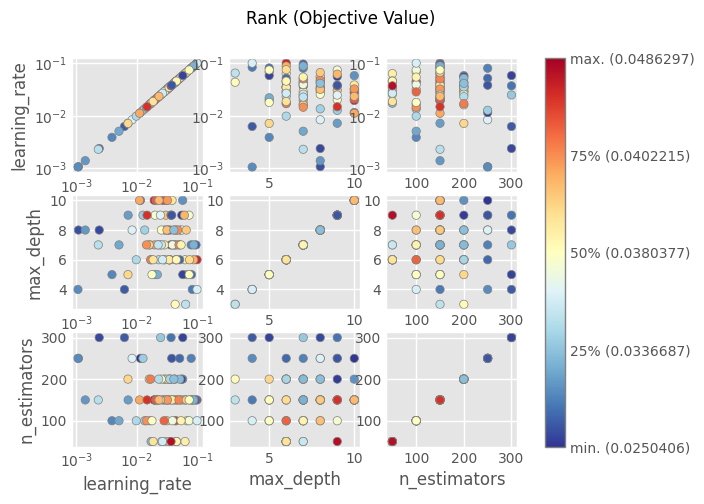

In [70]:
vis.plot_rank(study)
plt.savefig(f'{path}/plot_rank.png')

#### Выполним расчет на оптимальных параметрах без новых признаков

In [90]:
import json

with open(f'{path}/best_params.json', 'r') as f:
    best_params = json.load(f)

best_params['random_state'] = est_params['random_state']
best_params['verbose'] = est_params['verbose']
best_params

{'n_estimators': 150,
 'max_depth': 8,
 'learning_rate': 0.05263174463929155,
 'random_state': 43,
 'verbose': False}

In [51]:
best_params = {
    'n_estimators': 150,
    'max_depth': 8,
    'learning_rate': 0.05263174463929155,
    'random_state': 43,
    'verbose': False
}

r_learner_model metrics_catboost_hyperparam = {'uplift_auc': 0.023, 'qini_auc': 0.0473, 'uplift_at_30': 0.0486}


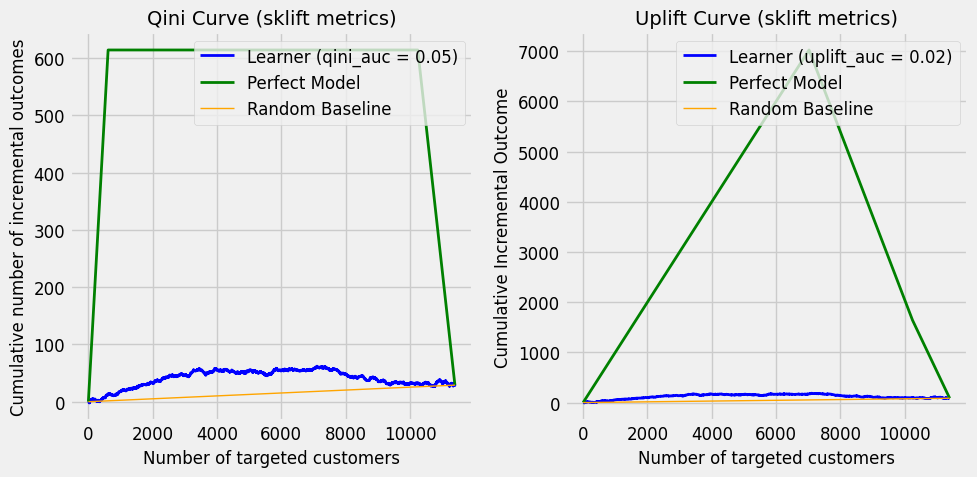

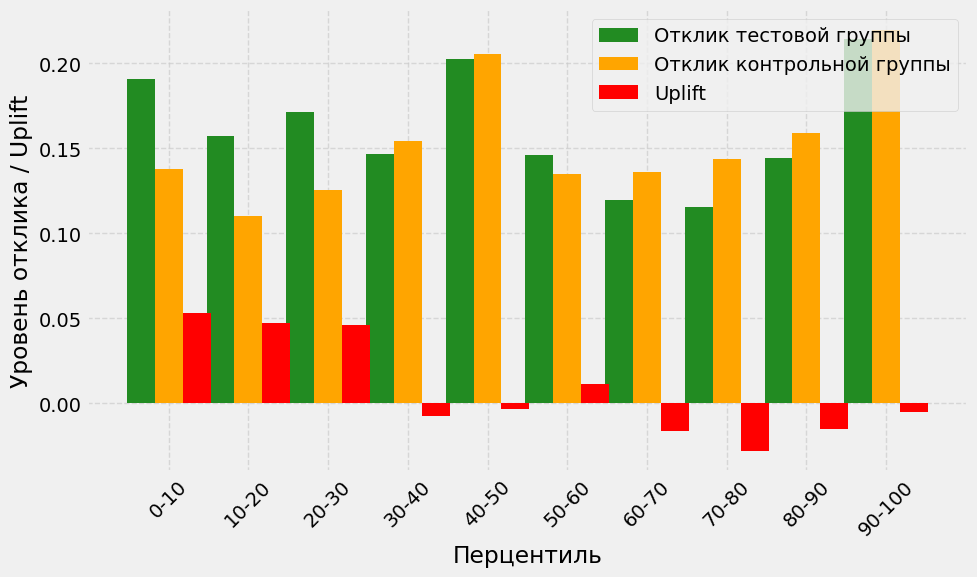

In [52]:
from causalml.inference.meta import BaseRLearner
import matplotlib.pyplot as plt
import utils
from catboost import CatBoostClassifier, CatBoostRegressor

est_outcome = CatBoostClassifier(cat_features=cat_features_indices, **best_params)
est_effect = CatBoostRegressor(cat_features=cat_features_indices, **best_params)
est_prop = CatBoostClassifier(cat_features=cat_features_indices, **best_params)

r_learner_model = BaseRLearner(
    n_fold=5,
    outcome_learner=est_outcome,
    effect_learner=est_effect,
    propensity_learner=est_prop,
    control_name=0,
    random_state=est_params['random_state']
    )

r_learner_model.fit(X=X_train_cat, treatment=treat_train, y=y_train)

# predict
r_learner_pred = r_learner_model.predict(X_test_cat).squeeze()

# metrics
metrics_catboost_hyperparam = utils.calc_uplift_metics(y_true=y_test, pred_uplift=r_learner_pred, treat_true=treat_test)
print(f'r_learner_model metrics_catboost_hyperparam = {metrics_catboost_hyperparam}')

# plot curve
fig, axs = plt.subplots(1, 2, figsize=(10, 5))
utils.plot_qini_curve(y_test, r_learner_pred, treat_test, axs=axs[0])
utils.plot_uplift_curve(y_test, r_learner_pred, treat_test, axs=axs[1])
plt.tight_layout()

fig = utils.custom_uplift_by_percentile(y_test, r_learner_pred, treat_test, kind='bar')
fig.show()

На этих параметрах модель менее сильно ошибается на старших перцентилях

#### Добавим новые признаки

r_learner_model metrics_catboost_hyperparam = {'uplift_auc': 0.0198, 'qini_auc': 0.0401, 'uplift_at_30': 0.0338}


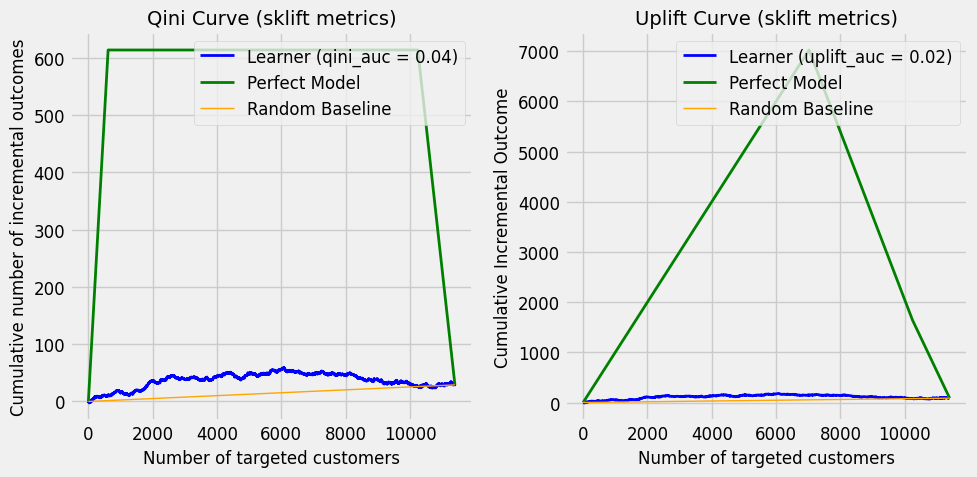

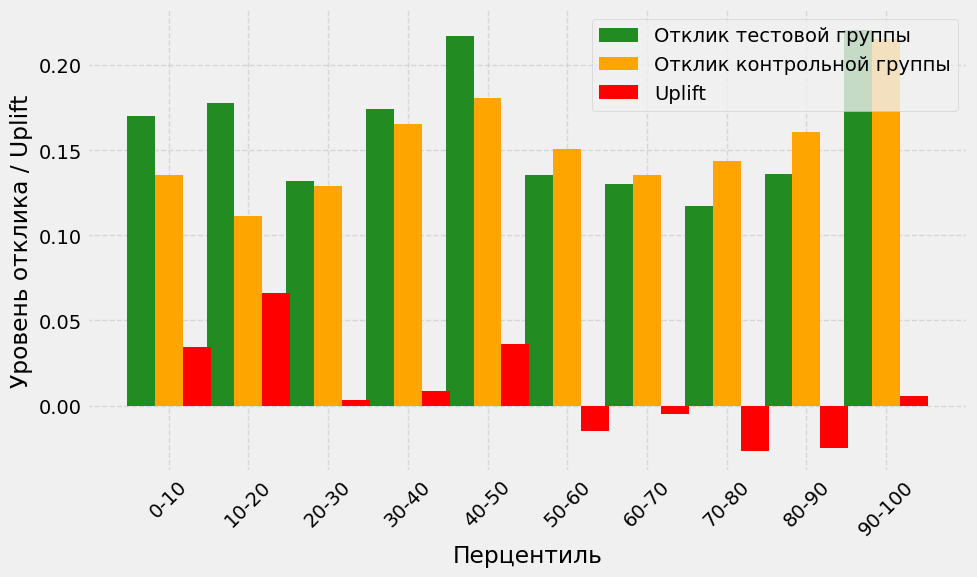

In [53]:
from causalml.inference.meta import BaseRLearner
import matplotlib.pyplot as plt
import utils
from catboost import CatBoostClassifier, CatBoostRegressor

X_train_cat_add = add_features(X_train_cat)
X_test_cat_add = add_features(X_test_cat)

est_outcome = CatBoostClassifier(cat_features=cat_features_indices, **best_params)
est_effect = CatBoostRegressor(cat_features=cat_features_indices, **best_params)
est_prop = CatBoostClassifier(cat_features=cat_features_indices, **best_params)

r_learner_model = BaseRLearner(
    n_fold=5,
    outcome_learner=est_outcome,
    effect_learner=est_effect,
    propensity_learner=est_prop,
    control_name=0,
    random_state=est_params['random_state']
    )

r_learner_model.fit(X=X_train_cat_add, treatment=treat_train, y=y_train)

# predict
r_learner_pred = r_learner_model.predict(X_test_cat_add).squeeze()

# metrics
metrics_catboost_hyperparam = utils.calc_uplift_metics(y_true=y_test, pred_uplift=r_learner_pred, treat_true=treat_test)
print(f'r_learner_model metrics_catboost_hyperparam = {metrics_catboost_hyperparam}')

# plot curve
fig, axs = plt.subplots(1, 2, figsize=(10, 5))
utils.plot_qini_curve(y_test, r_learner_pred, treat_test, axs=axs[0])
utils.plot_uplift_curve(y_test, r_learner_pred, treat_test, axs=axs[1])
plt.tight_layout()

fig = utils.custom_uplift_by_percentile(y_test, r_learner_pred, treat_test, kind='bar')
fig.show()

Получили ухудшение, чем без признаков

## Этап 2

### Визуализация результатов

In [ ]:
from utils import custom_uplift_by_percentile

В данной ячейке сделайте вывод о качестве работы модели и проинтерпретируйте график `uplift by percentile` 

## Этап 3

In [138]:
# Класс для инференса модели
class UpliftModelInference:
    """
    Класс для инференса uplift модели.
    """
    
    def __init__(self, model, feature_names, logger=None):
        """
        Инициализация класса.
        
        Аргументы:
            model: Обученная модель uplift
            feature_names: Список признаков для предсказания 
            logger: Объект для логирования (по умолчанию None)
        """
        self.model = model
        self.feature_names = ['recency', 'history_segment', 'history', 'mens', 'womens', 'zip_code', 'newbie', 'channel']
        self.logger = logger
        
        if self.logger:
            self.logger.info("Модель UpliftModel инициализирована с признаками: %s", feature_names)

    def _transform_data(self, X):
        """
        Преобразование данных для модели.
        
        Аргументы:
            X: pandas.DataFrame с признаками
        """
        if self.logger:
            self.logger.debug("Преобразование входных данных размерности %s", X.shape)

        # реализуйте преобразование данных для модели,
        # если в финальной модели используются новые признаки
       

        return X
    
    def predict(self, X):
        """
        Получение предсказаний uplift.
        
        Аргументы:
            X: pandas.DataFrame с признаками
            
        Возвращает:
            numpy.array с предсказанными значениями uplift
        """
        # Проверяем, что датафрейм не пустой
        if X.empty:
            if self.logger:
                self.logger.error("Предоставлен пустой датафрейм")
            return None
            
        # Проверяем наличие пропущенных значений
        if X.isnull().any().any():
            if self.logger:
                self.logger.error("Входные данные содержат пропущенные значения")
            return [None]*len(X)
        
        if self.logger:
            self.logger.info("Выполняем предсказания для данных размерности %s", X.shape)

        # Проверяем наличие всех необходимых признаков
        missing_features = set(self.feature_names) - set(X.columns)
        if missing_features:
            error_msg = f"Отсутствуют признаки: {missing_features}"
            if self.logger:
                self.logger.error(error_msg)

            return [None]*len(X)
        
        # Преобразуем данные для модели
        if self.logger:
            self.logger.debug("Начинаем преобразование данных")
        X = self._transform_data(X)
        
        # Вычисляем uplift
        if self.logger:
            self.logger.debug("Выполняем предсказания модели")
        

        # Дополните код для получения предсказаний аплифта

        
        if self.logger:
            self.logger.info("Предсказания успешно завершены")
            
        return uplift


In [126]:
model = UpliftModelInference(model= # ваш код,
                             feature_names= # ваш код)

In [ ]:
test_data = pd.DataFrame({
            'recency': [1, 2, 3],
            'history_segment': [1, 2, 3], 
            'history': [100, 200, 300],
            'mens': [1, 0, 1],
            'womens': [0, 1, 0],
            'zip_code': [1, 0, 1],
            'newbie': [0, 1, 0],
            'channel': [1, 2, 0]
        })

In [ ]:
# проверка работы класса
model.predict(test_data)